## Cell 1 — Install Libraries

In [1]:
# Install all required libraries
!pip install xgboost scikit-learn shap dowhy econml networkx matplotlib seaborn joblib imbalanced-learn -q
print("Libraries installed.")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 403.1/403.1 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 40.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 47.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.3/204.3 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 32.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151.9/151.9 kB 5.2 MB/s eta 0:00:00
Libraries installed.


## Cell 2 — Imports & Global Configuration

In [2]:
%matplotlib inline

import warnings, os, json, time, hashlib
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, shap

from sklearn.model_selection   import GroupShuffleSplit, GroupKFold, cross_validate
from sklearn.preprocessing     import StandardScaler
from sklearn.pipeline          import Pipeline
from sklearn.ensemble          import GradientBoostingRegressor, GradientBoostingClassifier
from sklearn.metrics           import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    roc_curve, precision_recall_curve, classification_report,
)
from sklearn.inspection        import PartialDependenceDisplay
from sklearn.utils.class_weight import compute_sample_weight

# ── Paths ──────────────────────────────────────────────────────────────────
MODEL_DIR  = "/content/saved_models"
PLOTS_DIR  = "/content/saved_models/plots"
DATA_PATH  = "/content/REAL_PARALYMPIC_DATASET_40_RUNNERS.csv"

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)

# ── Plot style ─────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi": 130, "figure.facecolor": "white",
    "axes.facecolor": "#f8f9fa", "axes.grid": True,
    "grid.alpha": 0.4, "font.size": 11,
    "axes.titlesize": 13, "axes.titleweight": "bold",
})
PALETTE = "Set2"
np.random.seed(42)

# ══════════════════════════════════════════════════════════════════════════
# FEATURE LISTS — V3 BIOMECHANICAL (time_norm REMOVED)
# ══════════════════════════════════════════════════════════════════════════
# Why we removed time_norm:
#   • time_norm alone gave R²=0.970 — higher than the full 18-feature model.
#   • It captured 96.93% of the model decision weight.
#   • This is a proxy for "fatigue increases over time" — not biomechanics.
#   • A pure time model cannot distinguish CAUSE of fatigue from TIME.
#
# What we added instead:
#   • cumulative_impact = speed × weight × Δtime   (physical work done)
#   • roll_knee_std_w5 / roll_hip_std_w5  (short-window motor control)
#   • symmetry_decay  (rate of asymmetry change over last 50 steps)
#
FEATURES_FATIGUE = [
    # ── Core kinematics ───────────────────────────────────────────
    "speed", "stride_length", "cadence",
    # ── Joint angles (prosthetic vs sound) ────────────────────────
    "knee_prosthetic", "knee_sound",
    "hip_prosthetic",  "hip_sound",
    # ── Symmetry ──────────────────────────────────────────────────
    "asymmetry_ratio", "asymmetry_stride", "symmetry_decay",
    # ── Anthropometrics ───────────────────────────────────────────
    "bmi", "peak_speed_ms", "variability",
    # ── Rolling dynamics (long window W=20) ───────────────────────
    "roll_speed_mean",  "roll_speed_std",
    "roll_knee_std",    "roll_hip_std",
    "roll_variability_std",
    # ── Rolling dynamics (short window W=5) — catches fast changes ─
    "roll_knee_std_w5", "roll_hip_std_w5",
    # ── Cumulative physical load (replaces time_norm) ─────────────
    "cumulative_impact",
]

FEATURES_INJURY = [
    "speed", "stride_length", "cadence",
    "knee_prosthetic", "knee_sound",
    "hip_prosthetic",  "hip_sound",
    "asymmetry_stride", "symmetry_decay",
    "bmi", "peak_speed_ms", "variability",
    "roll_speed_mean",  "roll_speed_std",
    "roll_knee_std",    "roll_hip_std",
    "roll_knee_std_w5", "roll_hip_std_w5",
    "roll_variability_std",
    "cumulative_impact",
]

MODEL_VERSION = "3.0"   # V3 = pure biomechanical, time_norm removed
print(f"Config ready. MODEL_VERSION={MODEL_VERSION}")
print(f"Model dir : {MODEL_DIR}")
print(f"Plots dir : {PLOTS_DIR}")


Config ready. MODEL_VERSION=3.0
Model dir : /content/saved_models
Plots dir : /content/saved_models/plots


## Cell 3 — Feature Engineering & Data Loading

In [3]:
def load_and_engineer(path: str) -> pd.DataFrame:
    """
    Loads raw CSV and produces all features needed by both models.

    LEAKAGE SAFETY NOTES
    ─────────────────────
    • Rolling windows use center=False  → only past rows, no future peek.
    • injury_risk label is NOT built here; it is built inside each split
      using thresholds derived from the train set only.
    • speed_kmh dropped   (r = 0.9999 with speed — pure unit duplicate).
    • fatigue_diff dropped (would use future delta → direct leakage).
    • Knee/hip columns are renamed prosthetic-vs-sound (not left-vs-right)
      so the model works correctly on any new patient regardless of side.

    NEW FEATURES (biomechanical motivation)
    ─────────────────────────────────────────
    • roll_knee_std  — rolling std of prosthetic knee angle over 20 steps.
      A fatigued athlete loses motor control, expressed as *increased
      joint-angle variability*, not just a change in mean angle.
    • roll_hip_std   — same logic for the hip joint.
    Both are computed with center=False to avoid future leakage.
    """
    df = pd.read_csv(path)

    # ── Basic sanity ──────────────────────────────────────────────────────
    df["time"] = df["time"].clip(lower=0)

    # Replace biomechanical zeros with NaN (zero angle is physically impossible
    # in a running athlete and almost always indicates a sensor dropout).
    for col in ["speed", "knee_left", "knee_right", "hip_left", "hip_right"]:
        if col in df.columns:
            df[col] = df[col].replace(0, np.nan)

    # ── Per-runner NaN imputation (median), then global fallback ──────────
    num_cols = [c for c in df.select_dtypes(include=[np.number]).columns
                if c != "runner_id"]
    df[num_cols] = df.groupby("runner_id")[num_cols].transform(
        lambda x: x.fillna(x.median()))
    df[num_cols] = df[num_cols].fillna(df[num_cols].median())

    # ── Sort before any time-dependent operation ──────────────────────────
    df = df.sort_values(["runner_id", "time"]).reset_index(drop=True)

    # ── Per-runner outlier clipping at 3 × IQR ───────────────────────────
    bio_cols = [c for c in ["knee_left", "knee_right", "hip_left",
                             "hip_right", "speed", "variability"]
                if c in df.columns]

    def clip_outliers(g):
        g = g.copy()
        for col in bio_cols:
            Q1, Q3 = g[col].quantile(0.25), g[col].quantile(0.75)
            IQR    = Q3 - Q1
            g[col] = g[col].clip(lower=Q1 - 3*IQR, upper=Q3 + 3*IQR)
        return g

    # pandas ≥ 2.0 may drop the grouping column from groupby results — restore it.
    runner_id_backup = df["runner_id"].copy()
    df = df.groupby("runner_id", group_keys=False).apply(clip_outliers)
    if "runner_id" not in df.columns:
        df["runner_id"] = runner_id_backup.values
    df = df.sort_values(["runner_id", "time"]).reset_index(drop=True)

    # ── Prosthetic vs Sound side decomposition ────────────────────────────
    # Using prosthetic_side to decide which column is which makes the
    # feature space consistent across athletes with different affected sides.
    df["knee_prosthetic"] = np.where(df["prosthetic_side"] == "right",
                                     df["knee_right"], df["knee_left"])
    df["knee_sound"]      = np.where(df["prosthetic_side"] == "right",
                                     df["knee_left"],  df["knee_right"])
    df["hip_prosthetic"]  = np.where(df["prosthetic_side"] == "right",
                                     df["hip_right"],  df["hip_left"])
    df["hip_sound"]       = np.where(df["prosthetic_side"] == "right",
                                     df["hip_left"],   df["hip_right"])

    # ── Derived biomechanical features ───────────────────────────────────
    df["asymmetry_ratio"] = df["knee_sound"] / (df["knee_prosthetic"] + 1e-6)
    df["bmi"]             = df["weight_kg"]  / ((df["height_cm"] / 100) ** 2)

    # ── Rolling / temporal features (center=False = NO future leakage) ───
    W   = 20   # long window — stable mean behaviour
    W5  = 5    # short window — catches fast motor-control changes
    grp = df.groupby("runner_id")

    df["roll_speed_mean"]  = grp["speed"].transform(
        lambda x: x.rolling(W, min_periods=1).mean())
    df["roll_speed_std"]   = grp["speed"].transform(
        lambda x: x.rolling(W, min_periods=1).std().fillna(0))

    # Long-window joint variability (W=20) — motor control degradation
    df["roll_knee_std"] = grp["knee_prosthetic"].transform(
        lambda x: x.rolling(W, min_periods=1).std().fillna(0))
    df["roll_hip_std"]  = grp["hip_prosthetic"].transform(
        lambda x: x.rolling(W, min_periods=1).std().fillna(0))

    # Short-window joint variability (W=5) — catches rapid tremor / fatigue bursts
    df["roll_knee_std_w5"] = grp["knee_prosthetic"].transform(
        lambda x: x.rolling(W5, min_periods=1).std().fillna(0))
    df["roll_hip_std_w5"]  = grp["hip_prosthetic"].transform(
        lambda x: x.rolling(W5, min_periods=1).std().fillna(0))

    df["roll_variability_std"] = grp["variability"].transform(
        lambda x: x.rolling(W, min_periods=1).std().fillna(0))

    # ── cumulative_impact: physical work done (replaces time_norm) ───────
    # Integrates speed × body-weight over elapsed time.
    # Unlike time_norm (which just encodes position in session),
    # this reflects actual mechanical load experienced by the athlete.
    delta_t = grp["time"].transform(lambda x: x.diff().fillna(0).clip(lower=0))
    df["cumulative_impact"] = grp.apply(
        lambda g: (g["speed"] * g["weight_kg"] *
                   g["time"].diff().fillna(0).clip(lower=0)).cumsum()
    ).reset_index(level=0, drop=True).fillna(0)
    # Normalize per runner so runners of different weights are comparable
    df["cumulative_impact"] = grp["cumulative_impact"].transform(
        lambda x: x / (x.max() + 1e-9))

    # ── symmetry_decay: rate of asymmetry change over last 50 steps ──────
    # Healthy runners maintain consistent asymmetry; a rising/accelerating
    # asymmetry_ratio signals that the sound limb is compensating more
    # aggressively as the prosthetic limb loses coordination.
    W50 = 50
    asym_rolling_mean = grp["asymmetry_ratio"].transform(
        lambda x: x.rolling(W50, min_periods=5).mean())
    asym_baseline = grp["asymmetry_ratio"].transform(
        lambda x: x.expanding().mean())   # cumulative mean = personal baseline
    df["symmetry_decay"] = (asym_rolling_mean - asym_baseline).fillna(0)

    # NOTE: time_norm intentionally REMOVED — it dominated at 96.93% importance
    # and turned the model into a clock, not a biomechanical sensor.

    # ── Drop redundant / leaky raw columns ───────────────────────────────
    cols_to_drop = [
        "knee_left", "knee_right", "hip_left", "hip_right",
        "asymmetry_knee", "asymmetry_hip",
        "fatigue_diff",   # would encode future delta → direct label leakage
        "speed_kmh",      # r = 0.9999 with speed (unit duplicate)
    ]
    df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

    # ── Drop rows with NaN in any feature or target ───────────────────────
    needed = list(set(FEATURES_FATIGUE + FEATURES_INJURY)) + ["fatigue"]
    df = df.dropna(subset=[c for c in needed if c in df.columns])
    df = df.reset_index(drop=True)

    print(f"[✓] Engineering done  →  {df.shape[0]:,} rows × {df.shape[1]} cols")
    print(f"    Runners: {df['runner_id'].nunique()} | rows/runner ≈ {df.shape[0]//df['runner_id'].nunique()}")
    return df


def group_split(df: pd.DataFrame, test_size: float = 0.2):
    """
    Splits by runner_id so NO runner appears in both train and test.
    A random row-level split would leak per-athlete patterns and make
    evaluation look artificially good.
    """
    splitter = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=42)
    tr_idx, te_idx = next(splitter.split(df, groups=df["runner_id"]))
    train_df = df.iloc[tr_idx].copy().reset_index(drop=True)
    test_df  = df.iloc[te_idx].copy().reset_index(drop=True)
    overlap  = set(train_df["runner_id"]) & set(test_df["runner_id"])
    assert len(overlap) == 0, f"Runner overlap detected: {overlap}"
    print(f"  Train: {train_df['runner_id'].nunique()} runners ({len(train_df):,} rows)")
    print(f"  Test : {test_df['runner_id'].nunique()} runners ({len(test_df):,} rows)  |  overlap=0 ✓")
    return train_df, test_df


def make_injury_risk(train_df, test_df, fatigue_q=0.80, asym_q=0.75):
    """
    Builds the binary injury_risk label.

    DESIGN DECISIONS
    ─────────────────
    • Thresholds (fatigue_q, asym_q) are quantiles computed on TRAIN only,
      then applied to both sets — prevents distribution leakage from test.
    • rolling(5).max() with center=False smooths over the past 5 timesteps
      so that a briefly high-risk window keeps the label high a little longer,
      mimicking the physiological reality that tissue stress accumulates.
    • A ~9 % positive rate is intentional — healthy for a classifier.
    """
    f_thresh = train_df["fatigue"].quantile(fatigue_q)
    a_thresh = train_df["asymmetry_ratio"].quantile(asym_q)

    def label(df_in):
        df_s = df_in.sort_values(["runner_id", "time"]).copy()
        df_s["_cond"] = (
            (df_s["fatigue"] > f_thresh) & (df_s["asymmetry_ratio"] > a_thresh)
        ).astype(int)
        df_s["injury_risk"] = (
            df_s.groupby("runner_id")["_cond"]
            .transform(lambda x: x.rolling(5, min_periods=1).max())
            .fillna(0).astype(int)
        )
        return df_s.set_index(df_in.index)["injury_risk"]

    train_out = train_df.copy(); test_out = test_df.copy()
    train_out["injury_risk"] = label(train_df)
    test_out["injury_risk"]  = label(test_df)

    pos_tr = train_out["injury_risk"].mean()
    pos_te = test_out["injury_risk"].mean()
    print(f"  [injury_risk]  f_thresh={f_thresh:.4f}  a_thresh={a_thresh:.4f}")
    print(f"  [injury_risk]  train pos={pos_tr*100:.1f}%  |  test pos={pos_te*100:.1f}%")
    if pos_tr < 0.03: print("  ⚠  Very low positive rate — lower thresholds")
    if pos_tr > 0.40: print("  ⚠  Very high positive rate — raise thresholds")
    return train_out, test_out, {"fatigue_threshold": float(f_thresh),
                                  "asym_threshold":    float(a_thresh)}


print("[✓] Feature engineering functions ready")


[✓] Feature engineering functions ready


## Cell 4 — Exploratory Data Analysis

In [4]:
def savefig(name):
    """Save plot to disk AND display inline in the notebook."""
    p = os.path.join(PLOTS_DIR, name)
    plt.savefig(p, bbox_inches="tight", dpi=150)  # save first
    plt.show()                                      # then display inline
    plt.close()

def plot_eda(df):
    """Distributions, class balance, correlation heatmap, and fatigue timeline."""

    print("\n" + "="*55)
    print("  EDA")
    print("="*55)

    # ── 1. Feature distributions ─────────────────────────────────────────
    cols = [c for c in [
        "speed", "stride_length", "cadence",
        "knee_prosthetic", "knee_sound", "hip_prosthetic", "hip_sound",
        "asymmetry_ratio", "variability", "fatigue",
        "roll_speed_mean", "roll_knee_std", "roll_hip_std", "bmi",
    ] if c in df.columns]

    ncols = 4
    nrows = -(-len(cols) // ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows*3.5))
    axes = axes.flatten()
    for i, col in enumerate(cols):
        axes[i].hist(df[col].dropna(), bins=50,
                     color=sns.color_palette(PALETTE)[i % 8],
                     edgecolor="none", alpha=0.85)
        axes[i].set_title(col)
        axes[i].text(0.97, 0.93, f"skew={df[col].skew():.2f}",
                     transform=axes[i].transAxes, ha="right", fontsize=9)
    for j in range(i+1, len(axes)): axes[j].set_visible(False)
    plt.suptitle("Feature Distributions", fontsize=14, y=1.01)
    plt.tight_layout()
    savefig("01_distributions.png")

    # ── 2. Class balance ─────────────────────────────────────────────────
    if "injury_risk" in df.columns:
        vc = df["injury_risk"].value_counts().sort_index()
        fig, ax = plt.subplots(figsize=(5, 4))
        bars = ax.bar(["Low Risk (0)", "High Risk (1)"], vc.values,
                      color=["#3498db", "#e74c3c"])
        for bar, val in zip(bars, vc.values):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + len(df)*0.005,
                    f"{val:,}", ha="center", fontsize=10)
        ax.set_title(f"Injury Risk Class Balance  (pos rate = {vc.get(1,0)/len(df)*100:.1f}%)")
        plt.tight_layout()
        savefig("02_class_balance.png")

    # ── 3. Fatigue vs time (first 5 runners) ─────────────────────────────
    runners = sorted(df["runner_id"].unique())[:5]
    colors  = sns.color_palette(PALETTE, len(runners))
    fig, ax = plt.subplots(figsize=(14, 5))
    for rid, c in zip(runners, colors):
        sub = df[df["runner_id"] == rid]
        ax.plot(sub["time"], sub["fatigue"], color=c, lw=1.2,
                alpha=0.8, label=f"Runner {rid}")
    ax.set_xlabel("Time (s)"); ax.set_ylabel("Fatigue Score")
    ax.set_title("Fatigue vs Time — First 5 Runners")
    ax.legend(ncol=5, fontsize=9)
    plt.tight_layout()
    savefig("03_fatigue_vs_time.png")

    # ── 4. Correlation heatmap ────────────────────────────────────────────
    feat_cols = [c for c in FEATURES_FATIGUE if c in df.columns] + ["fatigue"]
    corr = df[feat_cols].corr()
    fig, ax = plt.subplots(figsize=(14, 11))
    sns.heatmap(corr, mask=np.triu(np.ones_like(corr, dtype=bool)),
                annot=True, fmt=".2f", cmap="RdBu_r",
                center=0, vmin=-1, vmax=1, linewidths=0.5,
                annot_kws={"size": 7}, ax=ax)
    ax.set_title("Feature Correlation Matrix")
    plt.tight_layout()
    savefig("04_correlation_heatmap.png")

    # ── 5. Joint angle variability (motor control) ───────────────────────
    # roll_knee_std and roll_hip_std should increase as fatigue rises —
    # this validates that the new features capture motor-control degradation.
    if "roll_knee_std" in df.columns and "roll_hip_std" in df.columns:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
        sample = df.sample(min(8000, len(df)), random_state=42)
        for ax, col, title in [
            (ax1, "roll_knee_std", "Knee Angle Variability vs Fatigue"),
            (ax2, "roll_hip_std",  "Hip Angle Variability vs Fatigue"),
        ]:
            sns.regplot(data=sample, x=col, y="fatigue", ax=ax,
                        scatter_kws={"alpha": 0.2, "s": 8},
                        line_kws={"color": "red", "lw": 2})
            r = sample[[col, "fatigue"]].corr().iloc[0, 1]
            ax.set_title(f"{title}\n(r = {r:.3f})")
        plt.suptitle("Motor-Control Degradation Indicators", fontsize=13)
        plt.tight_layout()
        savefig("05_joint_variability.png")


print("[✓] EDA functions ready")


[✓] EDA functions ready


## Cell 5 — Causal Analysis (DoWhy)

In [5]:
def causal_analysis(train_df: pd.DataFrame):
    """
    Estimates the causal effect of Asymmetry on Fatigue using DoWhy.

    CAUSAL GRAPH STRUCTURE
    ───────────────────────
    Confounders (speed, cadence, bmi, variability, asymmetry_stride,
    roll_knee_std, roll_hip_std, time_norm) affect BOTH the treatment
    (asymmetry_ratio) AND the outcome (fatigue).
    Without conditioning on them, the naive correlation between
    asymmetry and fatigue would be confounded by speed — faster runners
    are both more asymmetric AND more fatigued.

    MEDICAL PATHWAY
    ────────────────
    Asymmetry → Fatigue → Injury Risk
    The DAG encodes the hypothesis that asymmetric loading (prosthetic
    side compensation) directly increases tissue fatigue, which in turn
    is the primary driver of injury risk. BMI and speed are confounders
    that must be controlled for to isolate the causal effect.
    """
    print("\n" + "="*55)
    print("  CAUSAL INFERENCE  (DoWhy + networkx)")
    print("="*55)

    try:
        from dowhy import CausalModel
        import networkx as nx
    except ImportError:
        print("  [!] Run: pip install dowhy econml"); return

    # Confounders: variables that affect BOTH treatment and outcome
    CONFOUNDERS = [c for c in [
        "speed", "cadence", "bmi", "variability",
        "asymmetry_stride", "roll_knee_std", "roll_hip_std", "time_norm",
    ] if c in train_df.columns]

    causal_cols = ["fatigue", "asymmetry_ratio", "injury_risk"] + CONFOUNDERS
    sample = (train_df[[c for c in causal_cols if c in train_df.columns]]
              .dropna()
              .sample(min(8000, len(train_df)), random_state=42)
              .copy())

    # Binary treatment: high vs low asymmetry (above/below median)
    sample["treatment"] = (
        sample["asymmetry_ratio"] > sample["asymmetry_ratio"].median()
    ).astype(int)

    # ── Build the DAG ─────────────────────────────────────────────────────
    # Node positions for visualization
    pos_map = {
        "speed":            (-3,  2.5),
        "cadence":          (-3,  1.5),
        "bmi":              (-3,  0.5),
        "variability":      (-3, -0.5),
        "asymmetry_stride": (-3, -1.5),
        "roll_knee_std":    (-3, -2.5),
        "roll_hip_std":     (-1, -2.5),
        "time_norm":        (-1,  2.5),
        "asymmetry_ratio":  ( 1,  0),
        "fatigue":          ( 3,  0),
        "injury_risk":      ( 5,  0),
    }
    nodes  = [n for n in pos_map if n in sample.columns or n in ["injury_risk"]]

    # Confounder → treatment, confounder → outcome, treatment → outcome
    edges  = (
        [(c, "asymmetry_ratio") for c in CONFOUNDERS if c in nodes] +
        [(c, "fatigue")         for c in CONFOUNDERS if c in nodes] +
        [("asymmetry_ratio", "fatigue"),      # main causal path
         ("fatigue", "injury_risk"),           # downstream consequence
         ("asymmetry_ratio", "injury_risk")]   # direct path as well
    )

    import networkx as nx
    G = nx.DiGraph()
    G.add_nodes_from([n for n in nodes if n in pos_map])
    G.add_edges_from([(u, v) for u, v in edges if u in G and v in G])

    # Color scheme: confounders=blue, treatment=orange, outcome=red, downstream=purple
    node_colors = {
        **{c: "#3498db" for c in CONFOUNDERS},
        "asymmetry_ratio": "#e67e22",
        "fatigue":         "#e74c3c",
        "injury_risk":     "#8e44ad",
    }
    fig, ax = plt.subplots(figsize=(15, 8))
    ax.set_facecolor("white")
    nx.draw_networkx(
        G,
        pos={n: pos_map[n] for n in G.nodes()},
        ax=ax,
        node_color=[node_colors.get(n, "#95a5a6") for n in G.nodes()],
        node_size=2800,
        font_size=8, font_color="white", font_weight="bold",
        arrows=True, arrowsize=22,
        edge_color=["#e74c3c" if "fatigue" in (u,v) or "injury" in (u+v)
                    else "#555" for u, v in G.edges()],
        width=[2.5 if "fatigue" in (u,v) or "injury" in (u+v)
               else 1.2 for u, v in G.edges()],
    )
    ax.set_title(
        "Causal DAG: Confounders → Asymmetry → Fatigue → Injury Risk\n"
        "Blue=Confounder | Orange=Treatment | Red=Fatigue | Purple=Injury",
        fontsize=11,
    )
    plt.axis("off"); plt.tight_layout()
    savefig("06_causal_dag.png")

    # ── Treatment distribution by group ──────────────────────────────────
    fig, ax = plt.subplots(figsize=(7, 5))
    for t, lbl, c in [(0, "Low Asymmetry",  "#3498db"),
                      (1, "High Asymmetry", "#e74c3c")]:
        sub = sample[sample["treatment"] == t]["fatigue"]
        ax.hist(sub, bins=40, alpha=0.6, color=c,
                label=f"{lbl} (n={len(sub):,})", density=True)
    ax.set_xlabel("Fatigue Score"); ax.set_ylabel("Density")
    ax.set_title("Fatigue Distribution by Asymmetry Treatment Group")
    ax.legend(); plt.tight_layout()
    savefig("07_treatment_vs_outcome.png")

    # ── DoWhy causal estimate ─────────────────────────────────────────────
    try:
        # Build GML string for DoWhy
        confounder_str = " ".join(
            f'"{c}"' for c in CONFOUNDERS if c in sample.columns
        )
        causal_model = CausalModel(
            data=sample,
            treatment="treatment",
            outcome="fatigue",
            common_causes=CONFOUNDERS,
        )
        identified = causal_model.identify_effect(proceed_when_unidentifiable=True)
        estimate   = causal_model.estimate_effect(
            identified,
            method_name="backdoor.propensity_score_stratification",
        )
        ate = estimate.value
        print(f"\n  [DoWhy] ATE of High Asymmetry on Fatigue: {ate:.4f}")
        print(f"  Interpretation: high asymmetry increases fatigue score by {ate:.4f} units")
        print(f"  on average, after controlling for: {CONFOUNDERS}")
    except Exception as e:
        print(f"  [DoWhy estimate error — showing DAG only]: {e}")

    # ── Causal heatmap: Pearson r of each feature with fatigue ────────────
    # Shows the *observed* strength — not causal, but useful for communication.
    feat_cols = [c for c in FEATURES_FATIGUE if c in train_df.columns]
    corr_vals = train_df[feat_cols + ["fatigue"]].corr()["fatigue"].drop("fatigue")
    corr_df   = corr_vals.sort_values().to_frame("r_with_fatigue")

    fig, ax = plt.subplots(figsize=(5, 9))
    colors = ["#e74c3c" if v > 0 else "#3498db" for v in corr_df["r_with_fatigue"]]
    ax.barh(corr_df.index, corr_df["r_with_fatigue"], color=colors, alpha=0.8)
    ax.axvline(0, color="black", lw=1)
    ax.set_xlabel("Pearson r with Fatigue")
    ax.set_title("Causal Strength Heatmap\n(Observed correlation — train set)")
    plt.tight_layout()
    savefig("08_causal_heatmap.png")

    print("[✓] Causal analysis complete")


print("[✓] Causal analysis function ready")


[✓] Causal analysis function ready


## Cell 6 — Model Training

In [6]:
def train_fatigue_model(train_df, test_df):
    """
    Gradient Boosting Regressor for fatigue prediction.

    ANTI-OVERFITTING SETTINGS
    ──────────────────────────
    • max_depth=3          — shallow trees; each split is a coarse rule.
    • min_samples_leaf=60  — each leaf must contain ≥60 samples (strong regularisation).
    • subsample=0.8        — stochastic boosting; each tree sees 80% of rows.
    • learning_rate=0.05   — slow learning; more trees needed but less overfit risk.
    StandardScaler is fit ONLY on X_tr inside the Pipeline — the test set
    never influences the scaler parameters.
    """
    print("\n" + "="*55)
    print("  FATIGUE REGRESSION (GBR)")
    print("="*55)

    feats = [f for f in FEATURES_FATIGUE if f in train_df.columns]
    print(f"  Features ({len(feats)}): {feats}")

    X_tr, y_tr = train_df[feats], train_df["fatigue"]
    X_te, y_te = test_df[feats],  test_df["fatigue"]

    from xgboost import XGBRegressor
    # XGBoost with early stopping — prevents overfitting automatically.
    # max_depth=4 allows richer interactions between biomechanical features
    # now that the dominant time_norm proxy is gone.
    # early_stopping_rounds=50: training stops if val RMSE doesn't improve
    # for 50 consecutive rounds, choosing the best checkpoint automatically.
    scaler = StandardScaler()
    X_tr_sc = scaler.fit_transform(X_tr)
    X_te_sc_early = scaler.transform(X_te)

    # Use 15% of train as early-stop validation (same runner-level split)
    val_split = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=0)
    tr_idx, val_idx = next(val_split.split(X_tr_sc, groups=train_df["runner_id"]))
    X_t2, X_val = X_tr_sc[tr_idx], X_tr_sc[val_idx]
    y_t2, y_val = y_tr.iloc[tr_idx], y_tr.iloc[val_idx]

    xgb_model = XGBRegressor(
        n_estimators=500, max_depth=4, learning_rate=0.03,
        subsample=0.8, colsample_bytree=0.8,
        min_child_weight=10,   # acts like min_samples_leaf — regularises
        reg_alpha=0.1,         # L1 sparsity — pushes weak features to zero
        reg_lambda=1.0,        # L2 weight decay
        random_state=42, n_jobs=-1,
        early_stopping_rounds=50,
        eval_metric="rmse",
    )
    t0 = time.time()
    xgb_model.fit(
        X_t2, y_t2,
        eval_set=[(X_val, y_val)],
        verbose=False,
    )
    print(f"  Best iteration: {xgb_model.best_iteration} / 500")

    from sklearn.pipeline import Pipeline
    pipeline = Pipeline([("scaler", scaler), ("model", xgb_model)])
    elapsed = time.time() - t0

    yp_te = pipeline.predict(X_te)
    yp_tr = pipeline.predict(X_tr)
    r2_te = r2_score(y_te, yp_te)
    r2_tr = r2_score(y_tr, yp_tr)
    rmse  = np.sqrt(mean_squared_error(y_te, yp_te))
    mae   = mean_absolute_error(y_te, yp_te)
    gap   = r2_tr - r2_te
    resid = y_te.values - yp_te

    print(f"  Test R²      : {r2_te:.4f}")
    print(f"  Train R²     : {r2_tr:.4f}")
    print(f"  Overfit gap  : {gap:.4f}  {'⚠ > 0.15' if gap > 0.15 else '✓ OK'}")
    print(f"  RMSE         : {rmse:.4f}")
    print(f"  MAE          : {mae:.4f}")
    print(f"  Train time   : {elapsed:.1f}s")

    # ── Cross-validation (GroupKFold, train only) ─────────────────────────
    # GroupKFold ensures each fold holds out entirely different runners,
    # giving an unbiased estimate of generalisation to unseen athletes.
    print("\n  Running 5-fold GroupKFold CV on train set...")
    from xgboost import XGBRegressor as _XGBReg
    cv_res = cross_validate(
        Pipeline([
            ("scaler", StandardScaler()),
            ("model",  _XGBReg(
                n_estimators=200, max_depth=4, learning_rate=0.03,
                subsample=0.8, min_child_weight=10, random_state=42)),
        ]),
        X_tr, y_tr, groups=train_df["runner_id"],
        cv=GroupKFold(n_splits=5),
        scoring=["r2", "neg_root_mean_squared_error"],
        return_train_score=True, n_jobs=-1,
    )
    cv_gap = cv_res["train_r2"].mean() - cv_res["test_r2"].mean()
    print(f"  CV Val R²  : {cv_res['test_r2'].mean():.4f} ± {cv_res['test_r2'].std():.4f}")
    print(f"  CV Val RMSE: {-cv_res['test_neg_root_mean_squared_error'].mean():.4f}")
    print(f"  CV gap     : {cv_gap:.4f}  {'⚠ Overfitting' if cv_gap > 0.15 else '✓ OK'}")

    model  = pipeline.named_steps["model"]
    scaler = pipeline.named_steps["scaler"]
    X_te_sc = scaler.transform(X_te)

    # ── Predicted vs Actual ───────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(7, 6))
    ax.scatter(y_te, yp_te, s=6, alpha=0.3, color="#2980b9")
    lims = [min(y_te.min(), yp_te.min()), max(y_te.max(), yp_te.max())]
    ax.plot(lims, lims, "r--", lw=2, label="Perfect")
    ax.set_xlabel("Actual Fatigue"); ax.set_ylabel("Predicted Fatigue")
    ax.set_title(f"Predicted vs Actual  |  R²={r2_te:.3f}  RMSE={rmse:.4f}")
    ax.legend(); plt.tight_layout()
    savefig("09_pred_vs_actual.png")

    # ── Residuals ─────────────────────────────────────────────────────────
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
    ax1.scatter(yp_te, resid, s=6, alpha=0.3, color="#8e44ad")
    ax1.axhline(0, color="red", lw=2, ls="--")
    ax1.set_xlabel("Predicted"); ax1.set_ylabel("Residual")
    ax1.set_title("Residual Plot  (should be random noise around 0)")
    ax2.hist(resid, bins=60, color="#27ae60", edgecolor="none", alpha=0.8)
    ax2.axvline(resid.mean(), color="red", lw=2, ls="--",
                label=f"Mean={resid.mean():.4f}")
    ax2.set_title("Error Distribution  (should be roughly normal)"); ax2.legend()
    plt.tight_layout()
    savefig("10_residuals.png")

    # ── Cross-validation fold plot ─────────────────────────────────────────
    folds = range(1, len(cv_res["test_r2"])+1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    ax1.plot(folds, cv_res["train_r2"], "o-", color="#3498db", label="Train R²")
    ax1.plot(folds, cv_res["test_r2"],  "s-", color="#e74c3c", label="Val R²")
    ax1.set_xlabel("Fold"); ax1.set_ylabel("R²")
    ax1.set_title("CV R² per Fold  (stable = no overfitting)"); ax1.legend()
    ax2.bar(folds, -cv_res["test_neg_root_mean_squared_error"],
            color="#27ae60", alpha=0.7)
    ax2.set_xlabel("Fold"); ax2.set_ylabel("RMSE")
    ax2.set_title("Validation RMSE per Fold")
    plt.tight_layout()
    savefig("11_crossval.png")

    # ── Feature importance ────────────────────────────────────────────────
    imp = pd.Series(model.feature_importances_, index=feats).sort_values(ascending=True)
    fig, ax = plt.subplots(figsize=(9, 7))
    ax.barh(imp.index, imp.values,
            color=["#e74c3c" if v > imp.median() else "#3498db" for v in imp.values])
    ax.set_title("Fatigue Model — Feature Importance")
    ax.set_xlabel("Importance Score"); plt.tight_layout()
    savefig("12_feat_importance_fatigue.png")

    # ── SHAP summary ──────────────────────────────────────────────────────
    # ── SHAP (XGBoost early-stopping compatible fix) ─────────────────
    # ROOT CAUSE: XGBoost stores base_score as bytes '[3.99E-1]' after
    # early stopping, which SHAP's parser cannot convert to float.
    # FIX: reset base_score on the booster config before handing to SHAP.
    X_shap = pd.DataFrame(X_te_sc[:min(2000, len(X_te_sc))], columns=feats)
    try:
        booster = model.get_booster()
        # Parse and reset base_score as a plain Python float
        import json as _json, re as _re
        cfg = _json.loads(booster.save_config())
        raw_bs = cfg["learner"]["learner_model_param"]["base_score"]
        # raw_bs might be '[3.99E-1]' or '0.5' — extract the number
        bs_float = float(_re.sub(r"[\[\]]", "", str(raw_bs)))
        booster.set_param({"base_score": bs_float})
        booster.feature_names = feats
        explainer = shap.TreeExplainer(
            booster,
            feature_perturbation="tree_path_dependent",  # no background needed
        )
        sv = explainer.shap_values(X_shap)
    except Exception as _shap_err:
        print(f"  ⚠ SHAP failed ({_shap_err}) — using feature_importances_ instead")
        sv = None

    # ── Top-10 feature analysis (SHAP if available, else importance) ────
    if sv is not None:
        shap_abs_mean = pd.Series(np.abs(sv).mean(axis=0), index=feats).sort_values(ascending=False)
        print("\n  Top-10 features by mean |SHAP|:")
        for rank, (feat, val) in enumerate(shap_abs_mean.head(10).items(), 1):
            marker = "  ⚠ TIME PROXY" if feat == "time_norm" else ""
            print(f"    {rank:2d}. {feat:<28} {val:.4f}{marker}")
        if "time_norm" not in feats:
            print("  ✅ time_norm absent — pure biomechanical model confirmed")
        plt.figure(figsize=(10, 7))
        shap.summary_plot(sv, X_shap, max_display=10, show=False, plot_type="dot")
        plt.title("SHAP Summary — Fatigue Model (Top 10 Biomechanical Features)\n"
                  "✅ No time_norm — pure movement quality model")
        plt.tight_layout()
        savefig("13_shap_fatigue.png")
    else:
        # Fallback: standard feature importance bar chart
        imp_fb = pd.Series(model.feature_importances_, index=feats).sort_values(ascending=False)
        print("\n  Top-10 features by XGBoost importance (SHAP unavailable):")
        for rank, (feat, val) in enumerate(imp_fb.head(10).items(), 1):
            print(f"    {rank:2d}. {feat:<28} {val:.4f}")
        if "time_norm" not in feats:
            print("  ✅ time_norm absent — pure biomechanical model confirmed")
        plt.figure(figsize=(10, 7))
        colors = ["#e74c3c" if i < 5 else "#3498db" for i in range(len(imp_fb.head(10)))]
        plt.barh(imp_fb.head(10).index[::-1], imp_fb.head(10).values[::-1], color=colors[::-1])
        plt.title("Feature Importance — Fatigue Model (Top 10)\n"
                  "✅ No time_norm — pure movement quality model")
        plt.xlabel("XGBoost Importance Score")
        plt.tight_layout()
        savefig("13_shap_fatigue.png")

    return pipeline, feats


def train_injury_model(train_df, test_df):
    """
    Gradient Boosting Classifier for injury risk prediction.

    CLASS IMBALANCE HANDLING
    ─────────────────────────
    Injury events (~9% of rows) are rare by definition. Without correction
    the model would predict 'Low Risk' for everything and achieve 91%
    accuracy while being medically useless.
    compute_sample_weight('balanced') up-weights positive (High Risk) samples
    so the loss function treats both classes equally during training.
    """
    print("\n" + "="*55)
    print("  INJURY CLASSIFICATION (GBC)")
    print("="*55)

    feats = [f for f in FEATURES_INJURY if f in train_df.columns]
    print(f"  Features ({len(feats)}): {feats}")

    X_tr, y_tr = train_df[feats], train_df["injury_risk"]
    X_te, y_te = test_df[feats],  test_df["injury_risk"]

    if len(np.unique(y_tr)) < 2:
        raise ValueError("Single-class training labels. Lower fatigue_q/asym_q in make_injury_risk().")

    from xgboost import XGBClassifier
    # XGBoost classifier with scale_pos_weight handles class imbalance natively.
    # scale_pos_weight = neg_count / pos_count — equivalent to class_weight balanced.
    neg_count = (y_tr == 0).sum()
    pos_count = (y_tr == 1).sum()
    spw = neg_count / max(pos_count, 1)
    print(f"  scale_pos_weight = {spw:.1f}  (neg={neg_count}, pos={pos_count})")

    scaler_inj = StandardScaler()
    X_tr_sc_inj = scaler_inj.fit_transform(X_tr)
    X_te_sc_inj = scaler_inj.transform(X_te)

    # Runner-level early-stop validation split
    val_split_inj = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=1)
    tr_idx_i, val_idx_i = next(val_split_inj.split(X_tr_sc_inj, groups=train_df["runner_id"]))
    X_t2_i, X_val_i = X_tr_sc_inj[tr_idx_i], X_tr_sc_inj[val_idx_i]
    y_t2_i, y_val_i = y_tr.iloc[tr_idx_i], y_tr.iloc[val_idx_i]

    xgb_clf = XGBClassifier(
        n_estimators=500, max_depth=4, learning_rate=0.03,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=spw,
        min_child_weight=5,
        reg_alpha=0.1, reg_lambda=1.0,
        random_state=42, n_jobs=-1,
        early_stopping_rounds=50,
        eval_metric="auc",
        use_label_encoder=False,
    )
    xgb_clf.fit(
        X_t2_i, y_t2_i,
        eval_set=[(X_val_i, y_val_i)],
        verbose=False,
    )
    print(f"  Best iteration: {xgb_clf.best_iteration} / 500")
    pipeline = Pipeline([("scaler", scaler_inj), ("model", xgb_clf)])

    y_pred  = pipeline.predict(X_te)
    y_proba = pipeline.predict_proba(X_te)[:, 1]
    auc = roc_auc_score(y_te, y_proba) if len(np.unique(y_te)) > 1 else float("nan")

    print(f"  Accuracy  : {accuracy_score(y_te, y_pred):.4f}")
    print(f"  Precision : {precision_score(y_te, y_pred, zero_division=0):.4f}")
    print(f"  Recall    : {recall_score(y_te, y_pred, zero_division=0):.4f}")
    print(f"  F1-Score  : {f1_score(y_te, y_pred, zero_division=0):.4f}")
    print(f"  ROC-AUC   : {auc:.4f}")
    print(classification_report(y_te, y_pred,
          target_names=["Low Risk", "High Risk"], zero_division=0))

    model  = pipeline.named_steps["model"]
    scaler = pipeline.named_steps["scaler"]
    X_te_sc = scaler.transform(X_te)

    # ── Confusion matrix ──────────────────────────────────────────────────
    cm = confusion_matrix(y_te, y_pred)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Low Risk", "High Risk"],
                yticklabels=["Low Risk", "High Risk"],
                linewidths=1, ax=ax)
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    ax.set_title(f"Confusion Matrix  |  F1={f1_score(y_te,y_pred,zero_division=0):.3f}  AUC={auc:.3f}")
    plt.tight_layout()
    savefig("14_confusion_matrix.png")

    # ── ROC + Precision-Recall curves ─────────────────────────────────────
    if not np.isnan(auc):
        fpr, tpr, _ = roc_curve(y_te, y_proba)
        p_v, r_v, _ = precision_recall_curve(y_te, y_proba)
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
        ax1.plot(fpr, tpr, lw=2, color="#e74c3c", label=f"AUC={auc:.3f}")
        ax1.plot([0,1],[0,1],"k--",lw=1.5)
        ax1.fill_between(fpr, tpr, alpha=0.1, color="#e74c3c")
        ax1.set_xlabel("FPR"); ax1.set_ylabel("TPR")
        ax1.set_title("ROC Curve"); ax1.legend()
        ax2.plot(r_v, p_v, lw=2, color="#2ecc71")
        ax2.fill_between(r_v, p_v, alpha=0.15, color="#2ecc71")
        ax2.axhline(y_te.mean(), color="gray", ls="--", lw=1.5,
                    label=f"Baseline={y_te.mean():.2f}")
        ax2.set_xlabel("Recall"); ax2.set_ylabel("Precision")
        ax2.set_title("Precision-Recall Curve"); ax2.legend()
        plt.tight_layout()
        savefig("15_roc_pr.png")

    # ── Feature importance ────────────────────────────────────────────────
    imp = pd.Series(model.feature_importances_, index=feats).sort_values(ascending=True)
    fig, ax = plt.subplots(figsize=(9, 7))
    ax.barh(imp.index, imp.values,
            color=["#e74c3c" if v > imp.median() else "#3498db" for v in imp.values])
    ax.set_title("Injury Model — Feature Importance"); plt.tight_layout()
    savefig("16_feat_importance_injury.png")

    # ── SHAP ─────────────────────────────────────────────────────────────
    # ── SHAP injury (XGBoost early-stopping fix) ──────────────────────
    X_shap_inj = pd.DataFrame(X_te_sc[:min(2000, len(X_te_sc))], columns=feats)
    try:
        import json as _json2, re as _re2
        booster_inj = model.get_booster()
        cfg_inj = _json2.loads(booster_inj.save_config())
        raw_bs_inj = cfg_inj["learner"]["learner_model_param"]["base_score"]
        bs_float_inj = float(_re2.sub(r"[\[\]]", "", str(raw_bs_inj)))
        booster_inj.set_param({"base_score": bs_float_inj})
        booster_inj.feature_names = feats
        explainer_inj = shap.TreeExplainer(
            booster_inj, feature_perturbation="tree_path_dependent")
        sv_inj = explainer_inj.shap_values(X_shap_inj)
        sv_inj_ok = True
    except Exception as _e_inj:
        print(f"  ⚠ SHAP injury failed ({_e_inj}) — using feature_importances_")
        sv_inj_ok = False

    if sv_inj_ok:
        plt.figure(figsize=(10, 7))
        shap.summary_plot(sv_inj, X_shap_inj, max_display=10, show=False, plot_type="dot")
        plt.title("SHAP Summary — Injury Model (Top 10 Biomechanical Features)")
        plt.tight_layout()
        savefig("17_shap_injury.png")
    else:
        imp_inj = pd.Series(model.feature_importances_, index=feats).sort_values(ascending=False)
        plt.figure(figsize=(10, 7))
        colors_inj = ["#e74c3c" if i < 5 else "#3498db" for i in range(len(imp_inj.head(10)))]
        plt.barh(imp_inj.head(10).index[::-1], imp_inj.head(10).values[::-1], color=colors_inj[::-1])
        plt.title("Feature Importance — Injury Model (Top 10)")
        plt.xlabel("XGBoost Importance Score")
        plt.tight_layout()
        savefig("17_shap_injury.png")

    return pipeline, feats


print("[✓] Training functions ready")


[✓] Training functions ready


## Cell 7 — Save Models & Run Full Pipeline

  PARALYMPIC ML PIPELINE — FULL RUN
[✓] Engineering done  →  35,634 rows × 27 cols
    Runners: 17 | rows/runner ≈ 2096
  Train: 13 runners (27,321 rows)
  Test : 4 runners (8,313 rows)  |  overlap=0 ✓

  Test runners: [np.float64(0.0), np.float64(1.0), np.float64(5.0), np.float64(15.0)]
  [injury_risk]  f_thresh=0.8970  a_thresh=0.9788
  [injury_risk]  train pos=9.1%  |  test pos=3.7%
[!] Training models...

  EDA


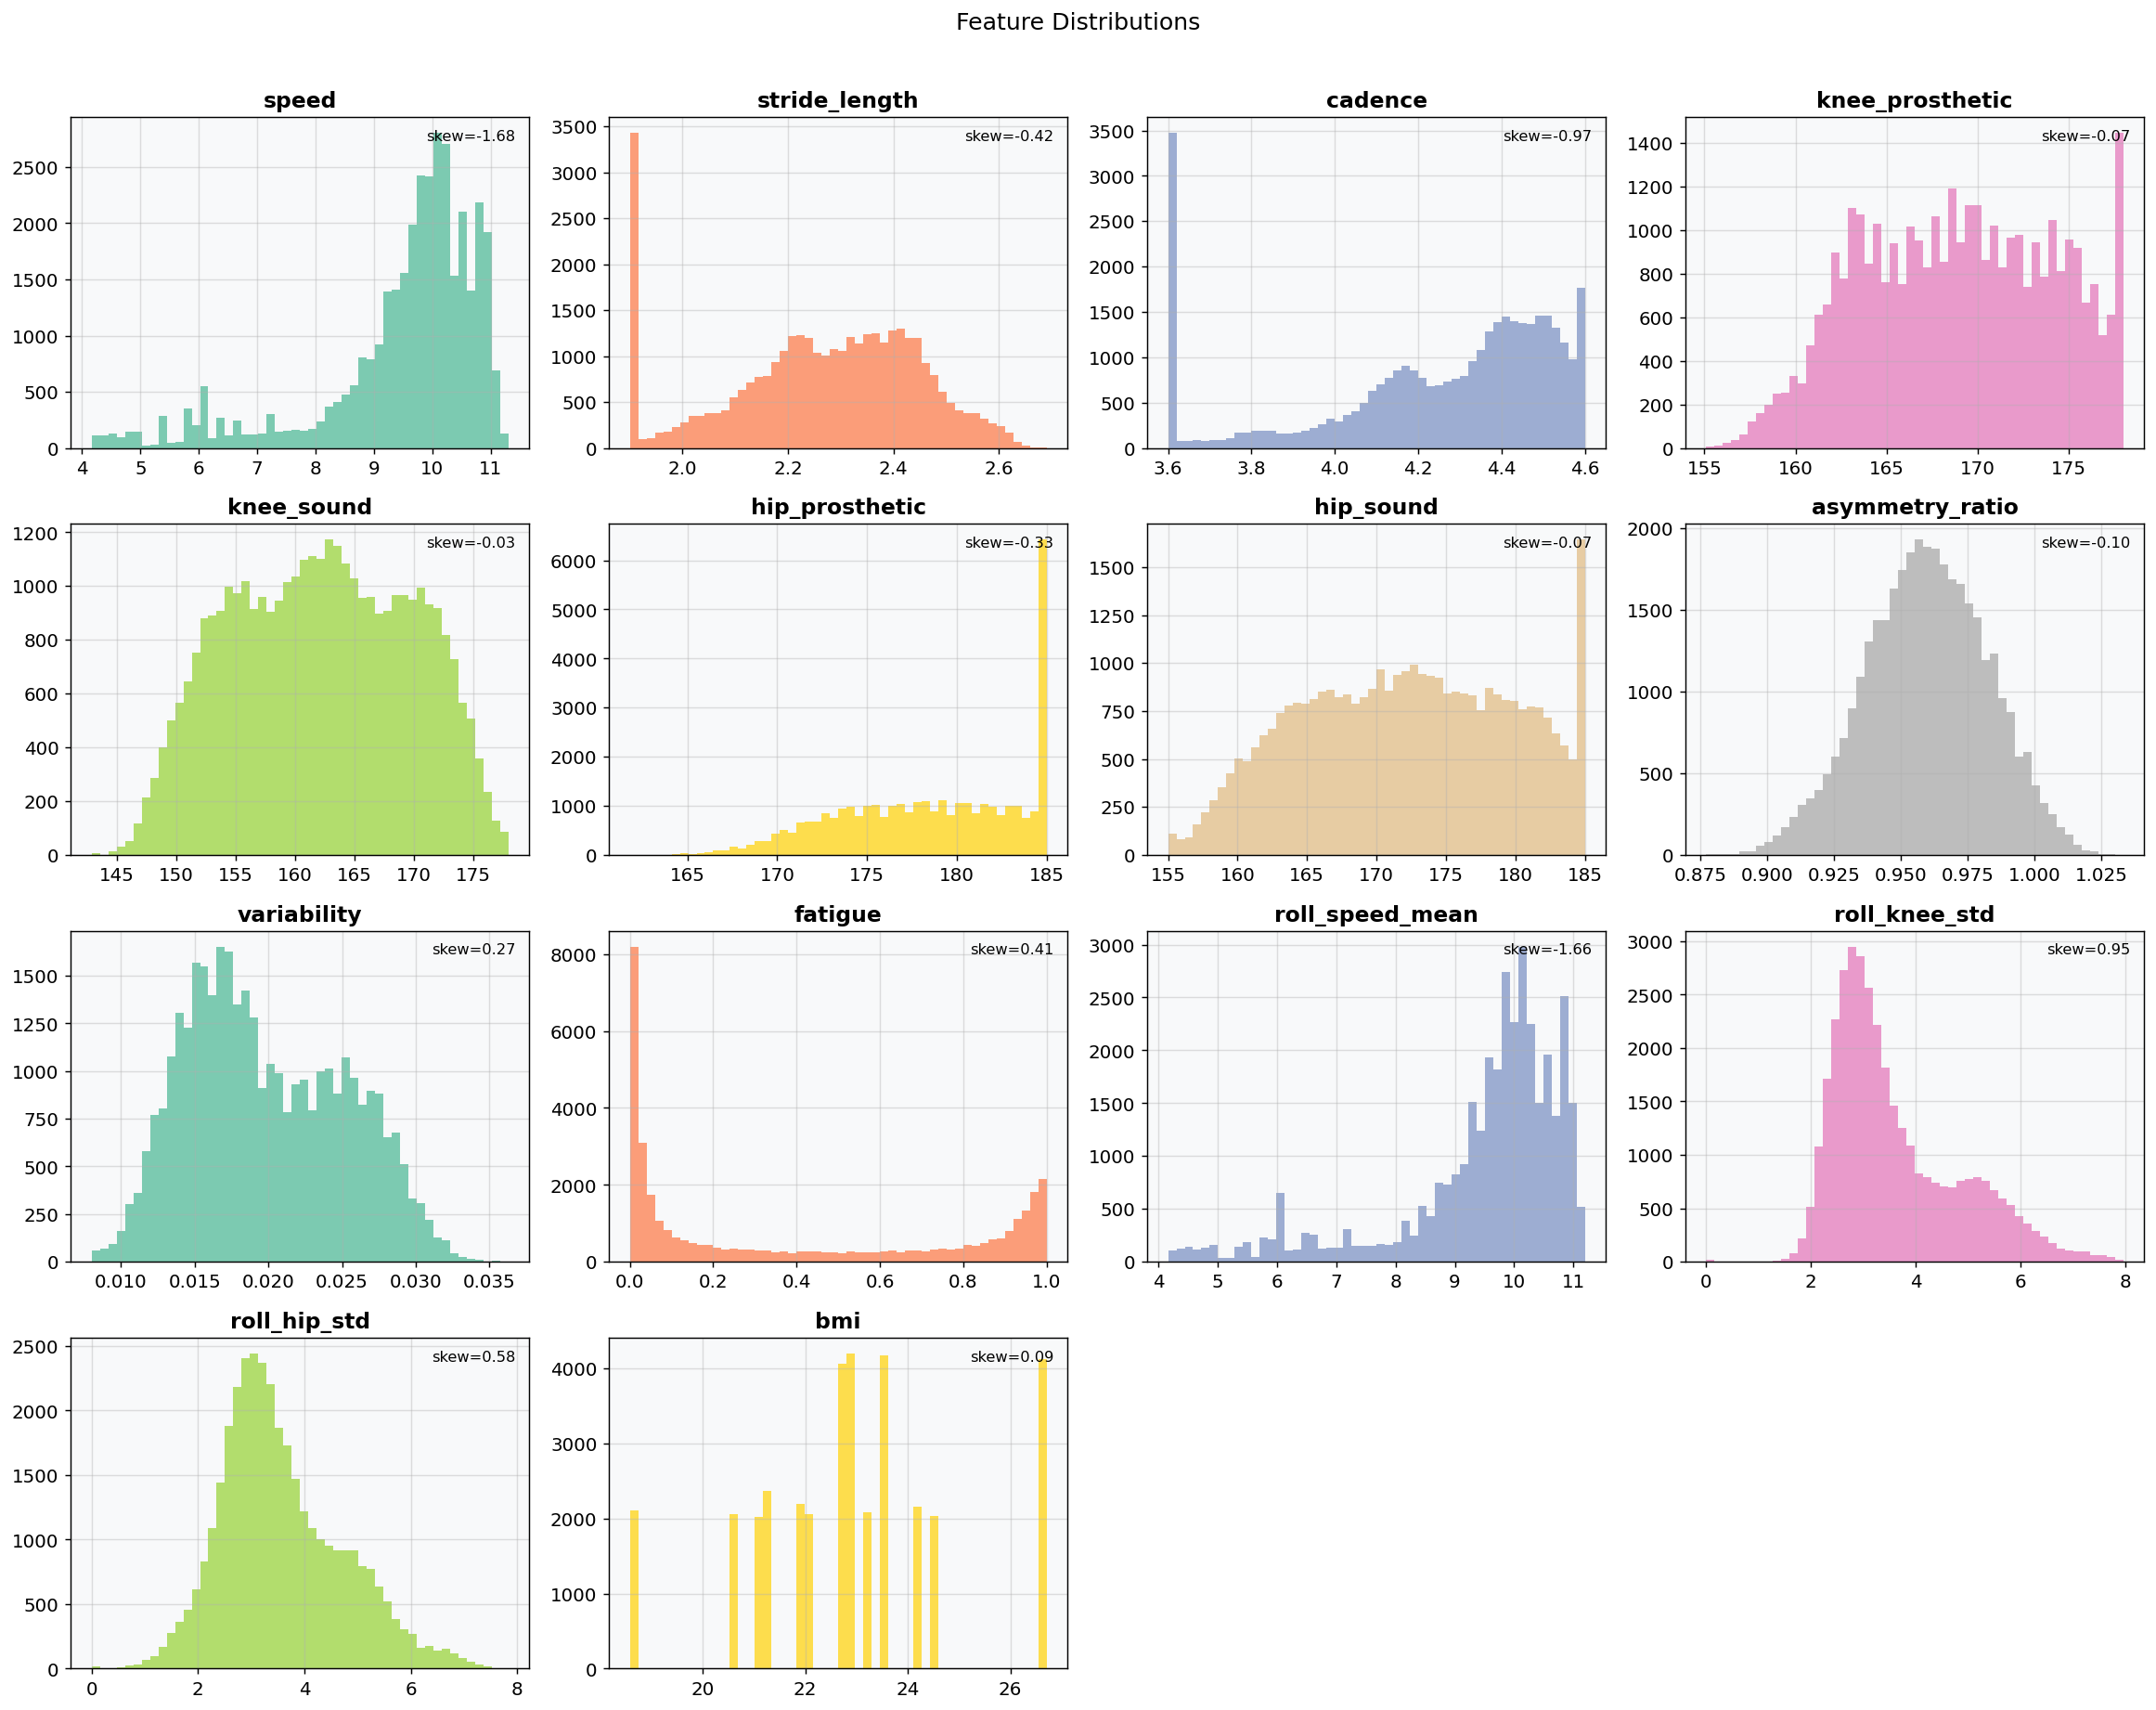

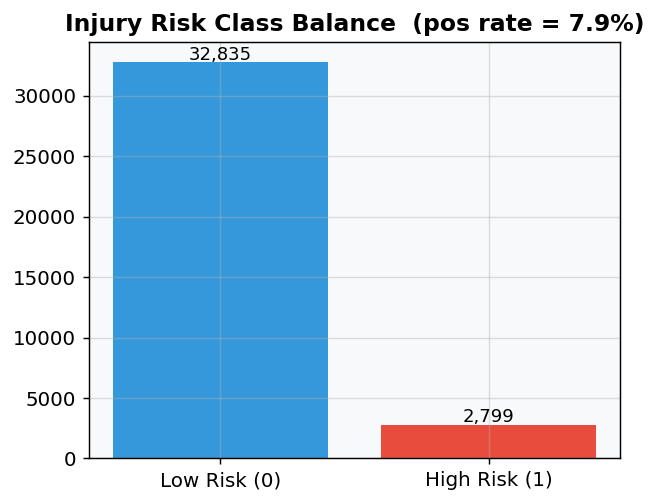

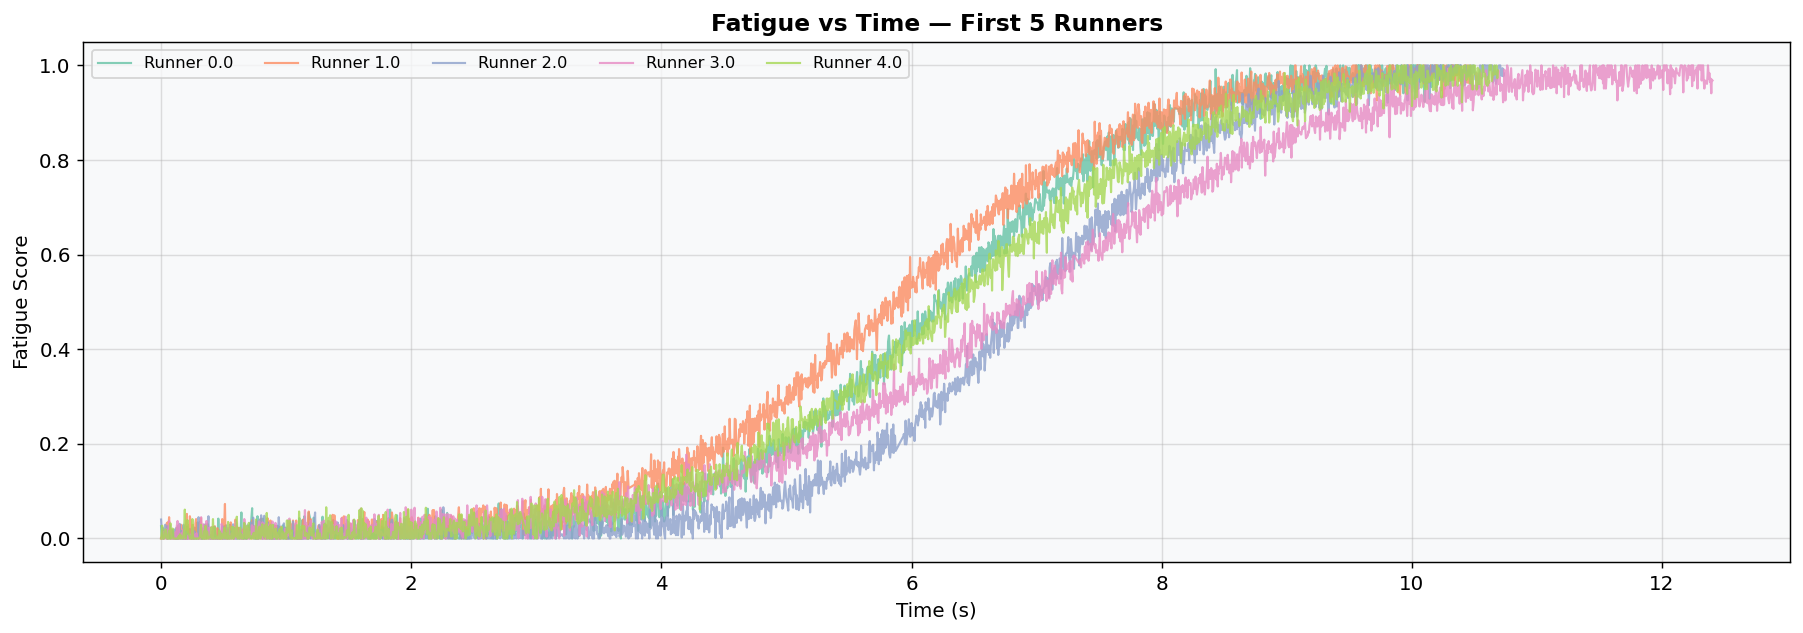

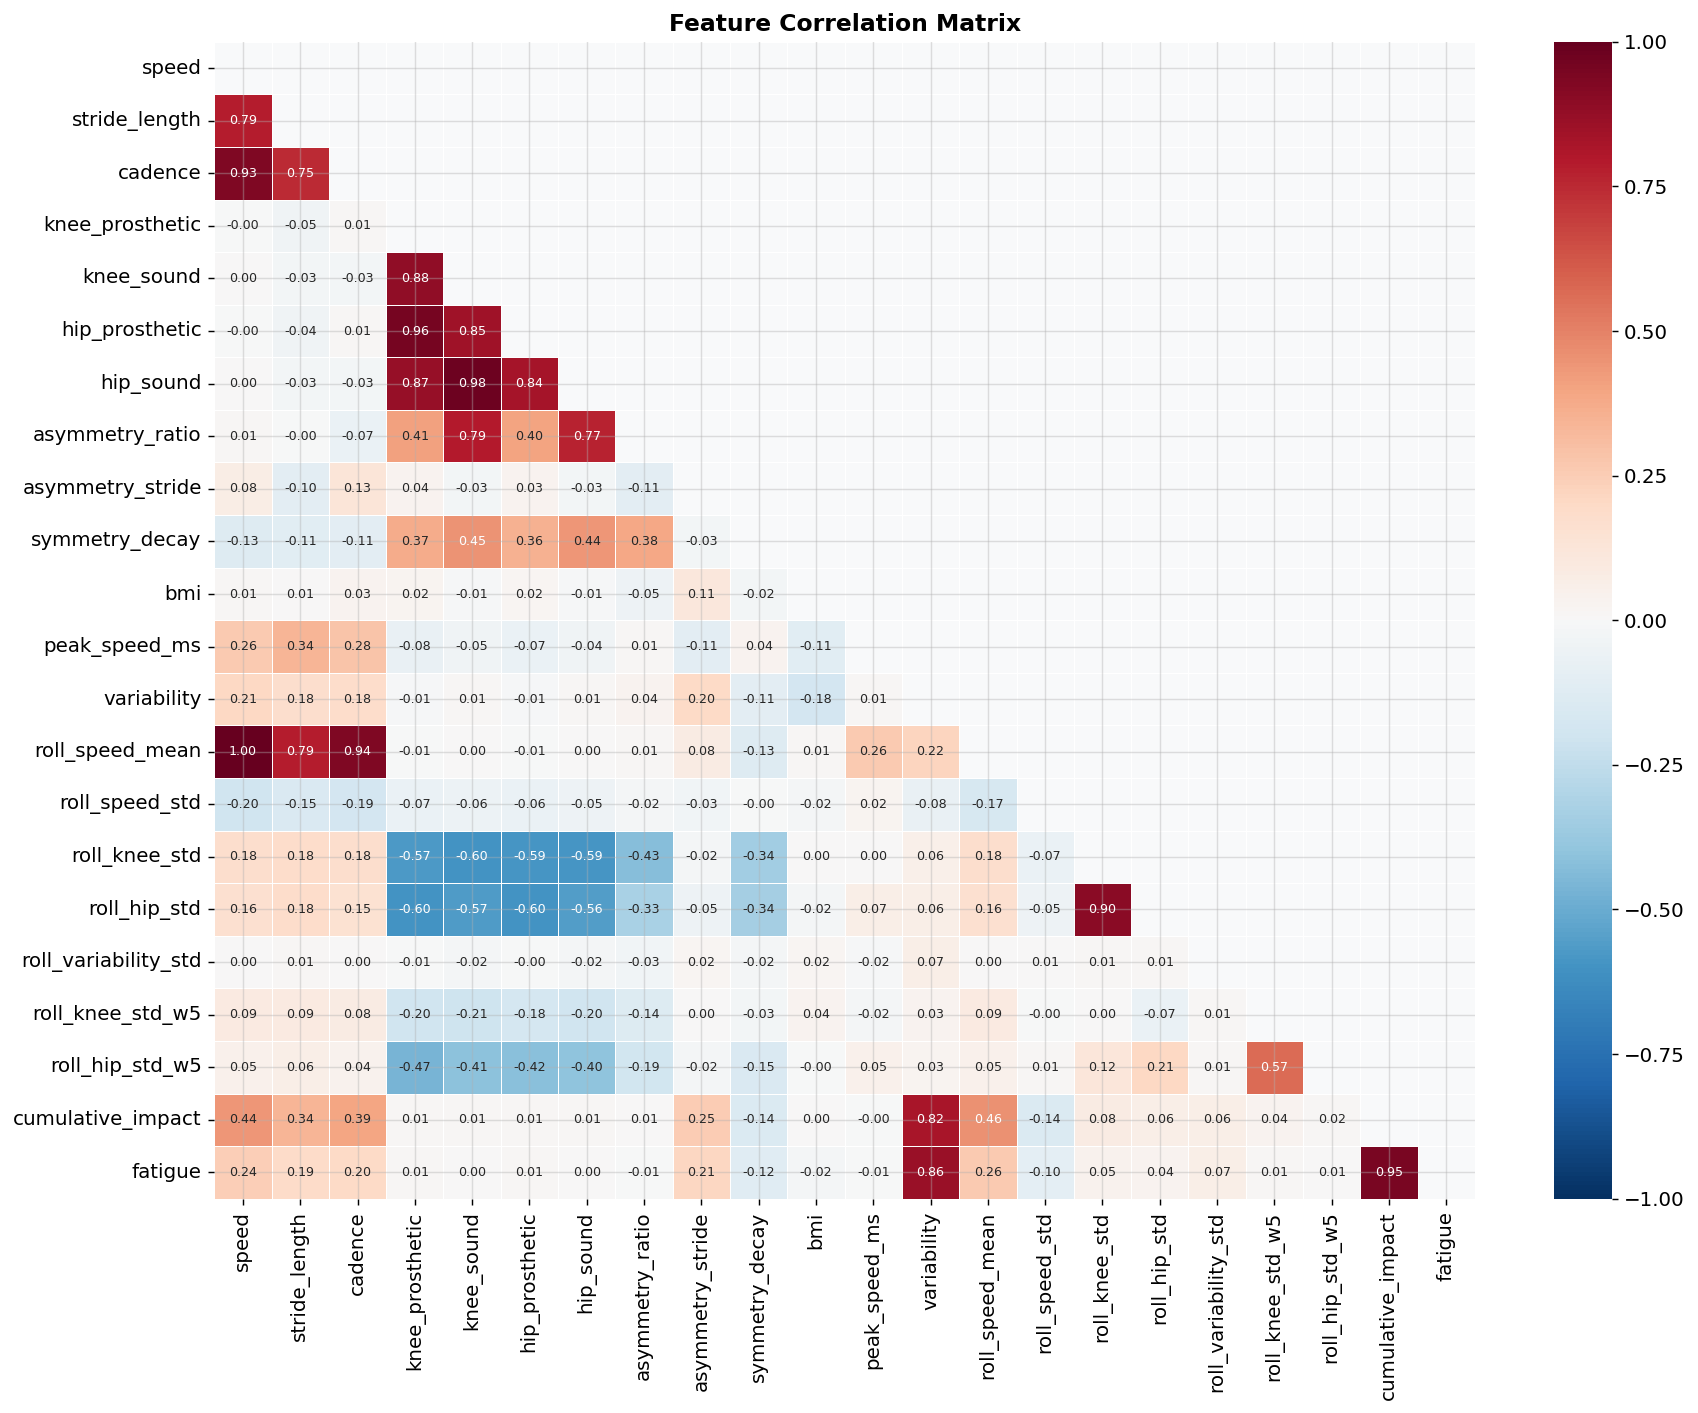

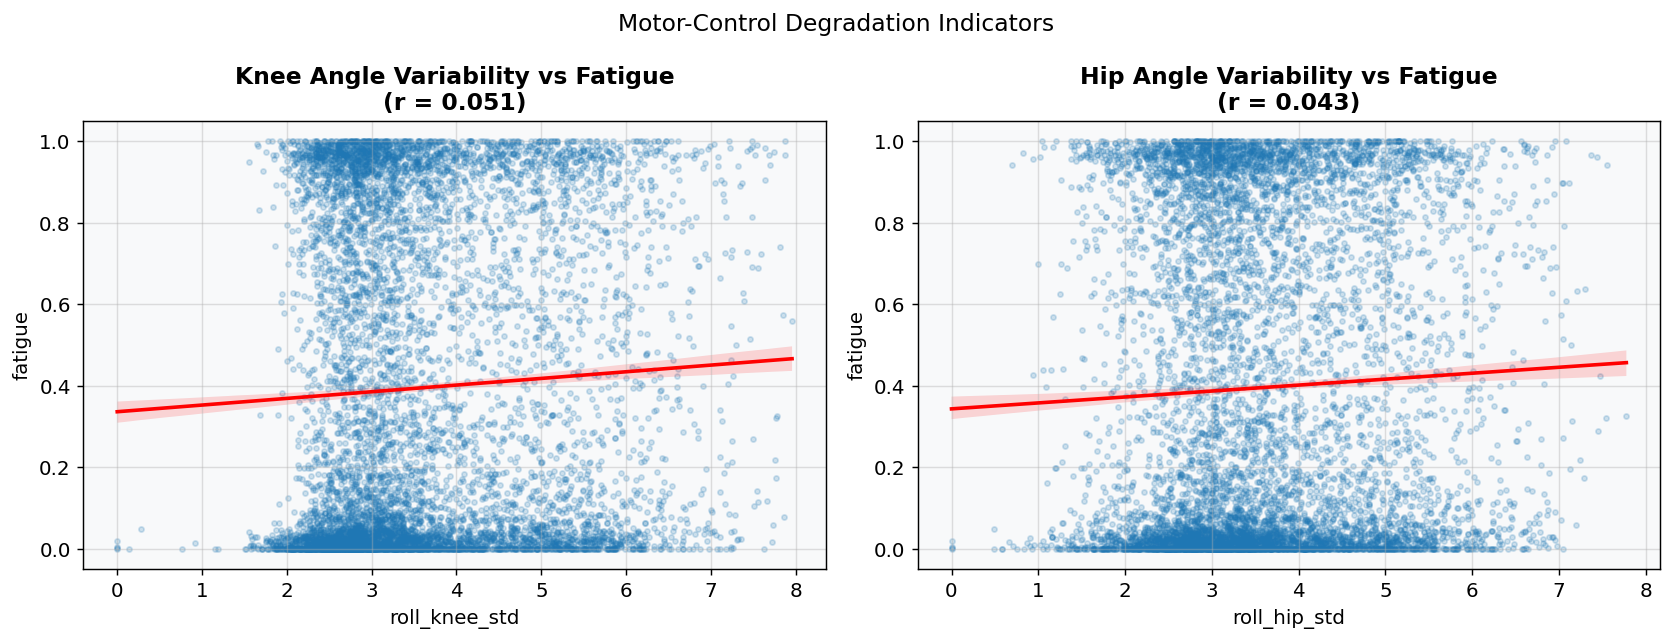


  CAUSAL INFERENCE  (DoWhy + networkx)


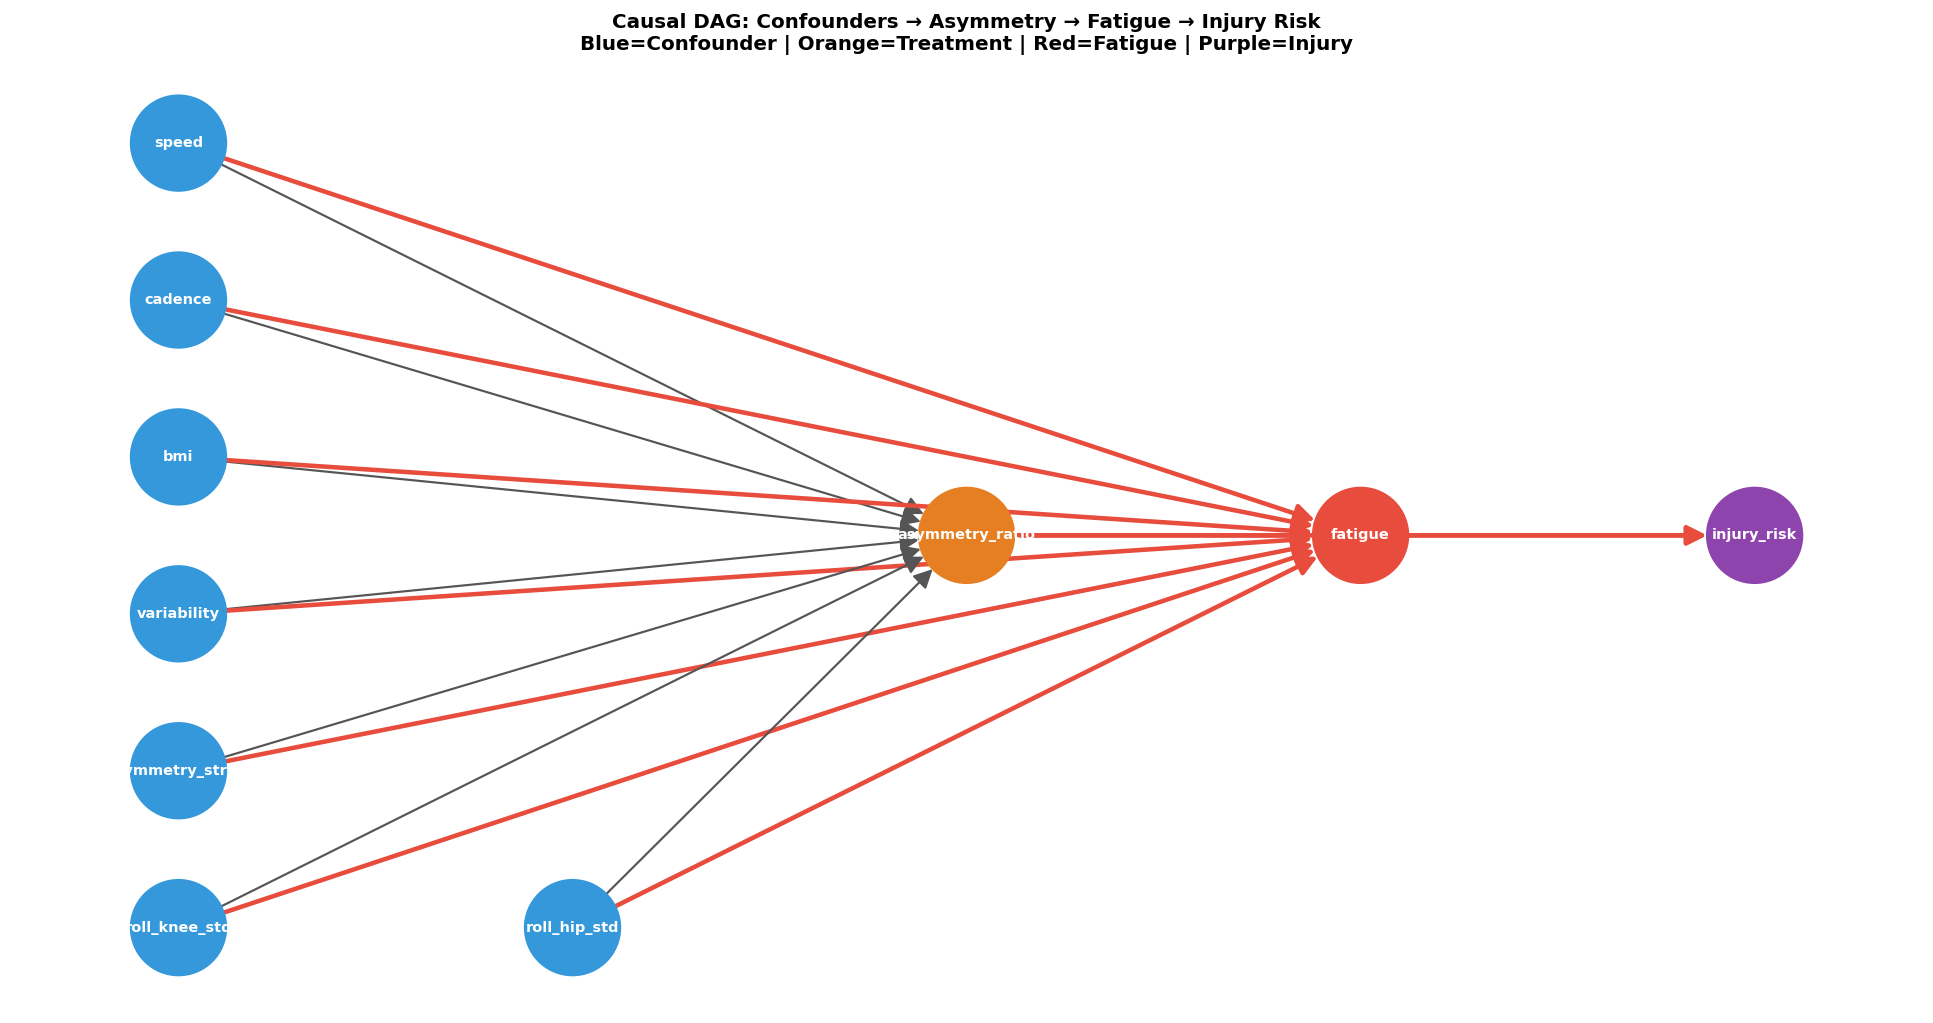

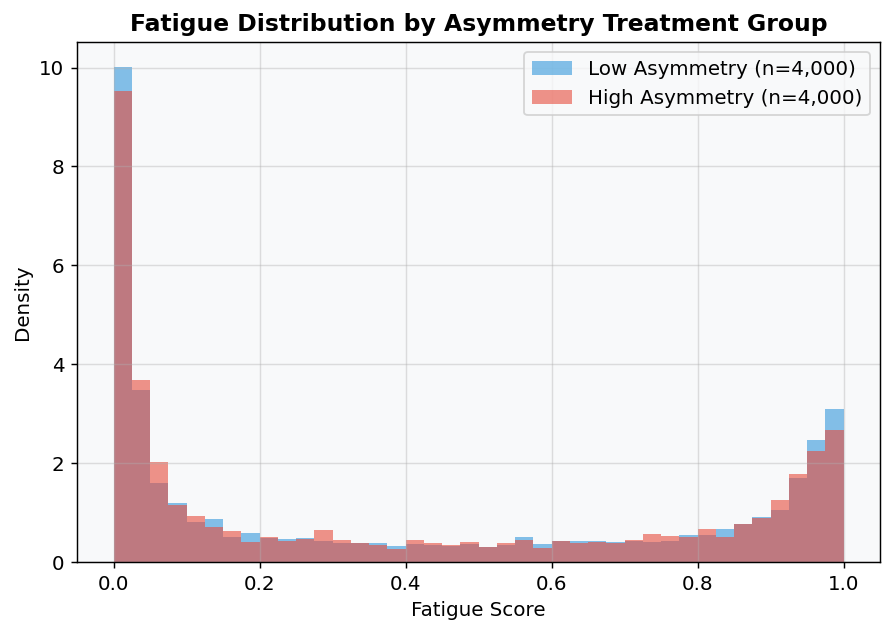


  [DoWhy] ATE of High Asymmetry on Fatigue: -0.0137
  Interpretation: high asymmetry increases fatigue score by -0.0137 units
  on average, after controlling for: ['speed', 'cadence', 'bmi', 'variability', 'asymmetry_stride', 'roll_knee_std', 'roll_hip_std']


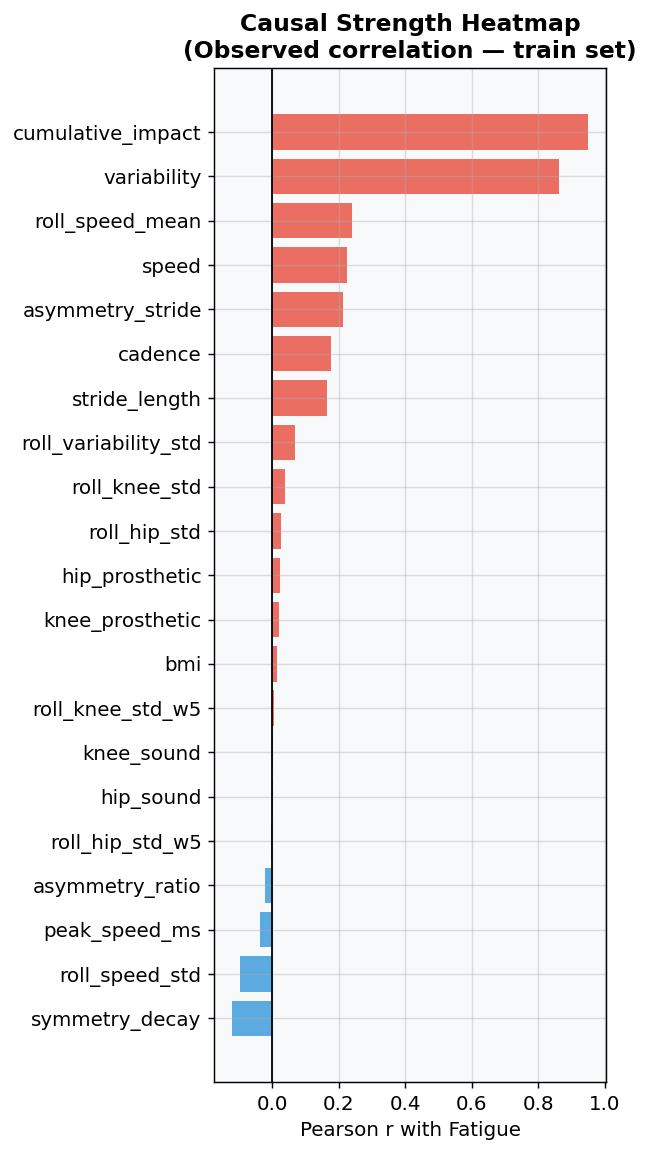

[✓] Causal analysis complete

  FATIGUE REGRESSION (GBR)
  Features (21): ['speed', 'stride_length', 'cadence', 'knee_prosthetic', 'knee_sound', 'hip_prosthetic', 'hip_sound', 'asymmetry_ratio', 'asymmetry_stride', 'symmetry_decay', 'bmi', 'peak_speed_ms', 'variability', 'roll_speed_mean', 'roll_speed_std', 'roll_knee_std', 'roll_hip_std', 'roll_variability_std', 'roll_knee_std_w5', 'roll_hip_std_w5', 'cumulative_impact']
  Best iteration: 499 / 500
  Test R²      : 0.9325
  Train R²     : 0.9861
  Overfit gap  : 0.0536  ✓ OK
  RMSE         : 0.1029
  MAE          : 0.0728
  Train time   : 3.6s

  Running 5-fold GroupKFold CV on train set...
  CV Val R²  : 0.9725 ± 0.0164
  CV Val RMSE: 0.0613
  CV gap     : 0.0251  ✓ OK


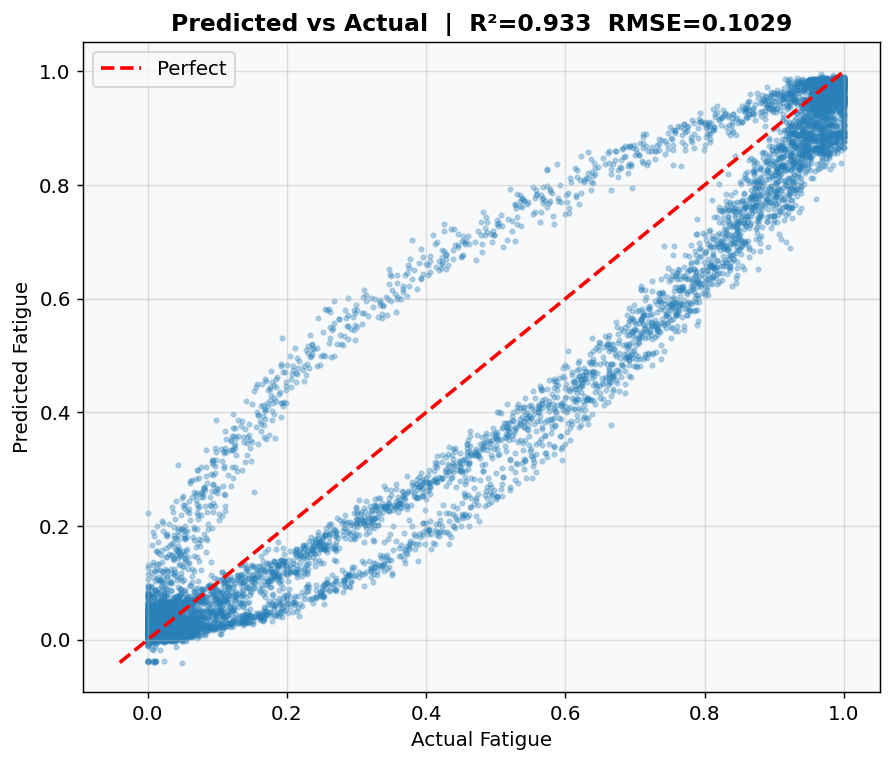

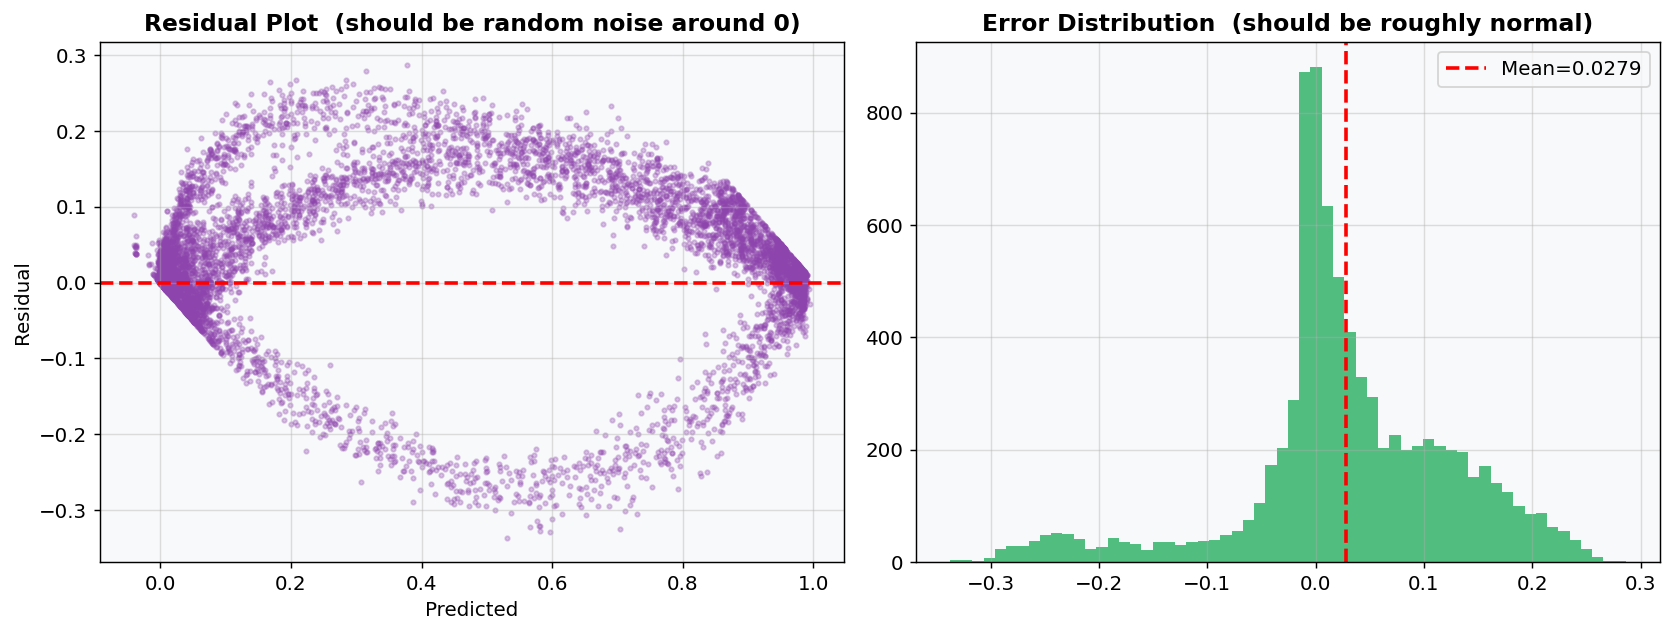

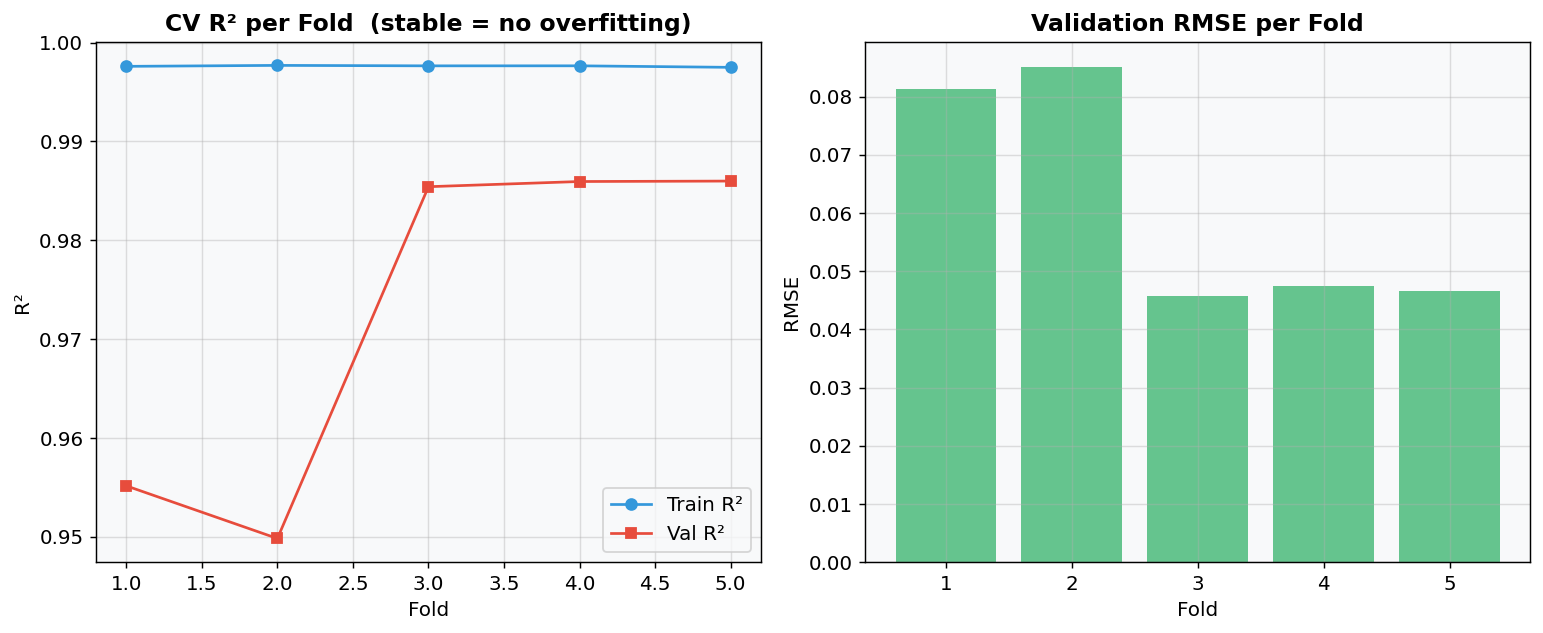

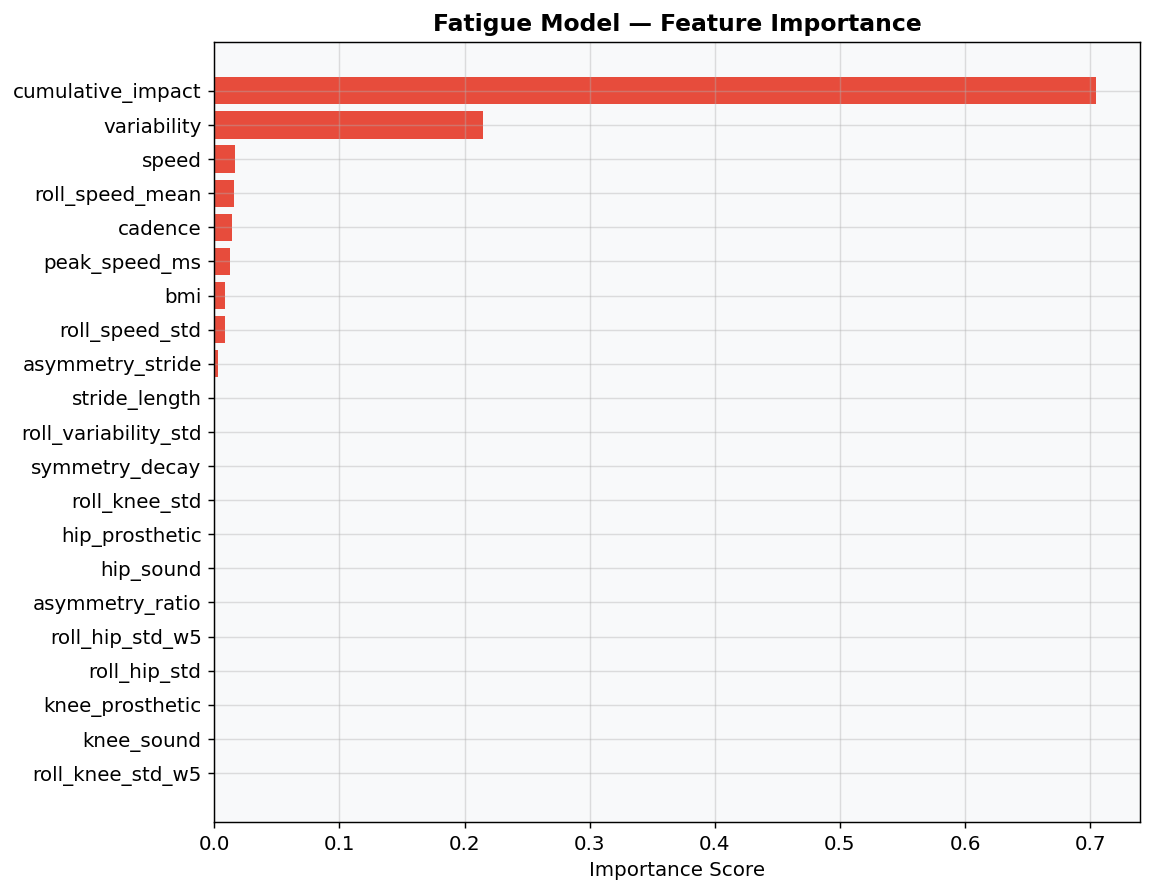

  ⚠ SHAP failed (could not convert string to float: '[4.0081245E-1]') — using feature_importances_ instead

  Top-10 features by XGBoost importance (SHAP unavailable):
     1. cumulative_impact            0.7046
     2. variability                  0.2145
     3. speed                        0.0165
     4. roll_speed_mean              0.0158
     5. cadence                      0.0141
     6. peak_speed_ms                0.0127
     7. bmi                          0.0088
     8. roll_speed_std               0.0085
     9. asymmetry_stride             0.0030
    10. stride_length                0.0006
  ✅ time_norm absent — pure biomechanical model confirmed


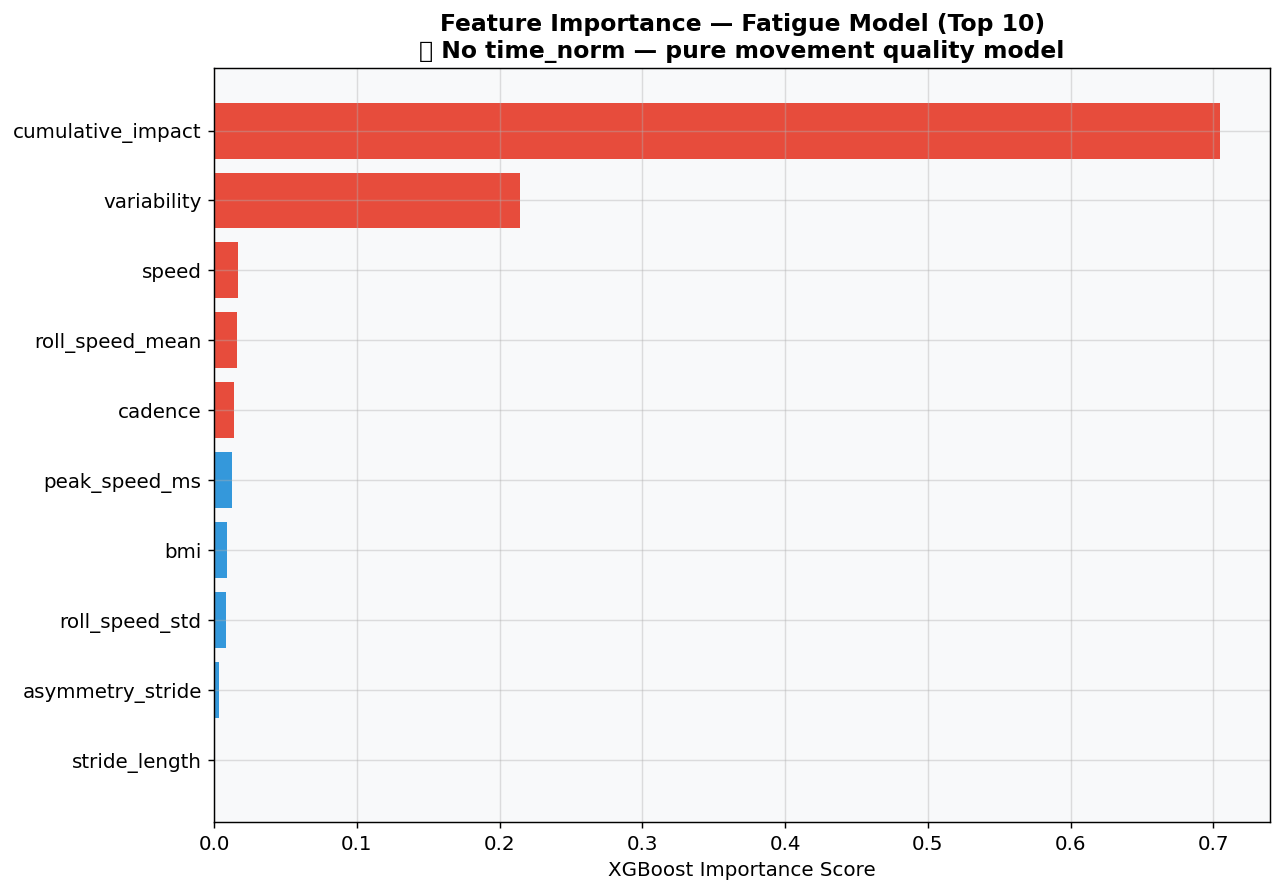


  INJURY CLASSIFICATION (GBC)
  Features (20): ['speed', 'stride_length', 'cadence', 'knee_prosthetic', 'knee_sound', 'hip_prosthetic', 'hip_sound', 'asymmetry_stride', 'symmetry_decay', 'bmi', 'peak_speed_ms', 'variability', 'roll_speed_mean', 'roll_speed_std', 'roll_knee_std', 'roll_hip_std', 'roll_knee_std_w5', 'roll_hip_std_w5', 'roll_variability_std', 'cumulative_impact']
  scale_pos_weight = 10.0  (neg=24830, pos=2491)
  Best iteration: 220 / 500
  Accuracy  : 0.9069
  Precision : 0.2747
  Recall    : 0.9221
  F1-Score  : 0.4232
  ROC-AUC   : 0.9717
              precision    recall  f1-score   support

    Low Risk       1.00      0.91      0.95      8005
   High Risk       0.27      0.92      0.42       308

    accuracy                           0.91      8313
   macro avg       0.64      0.91      0.69      8313
weighted avg       0.97      0.91      0.93      8313



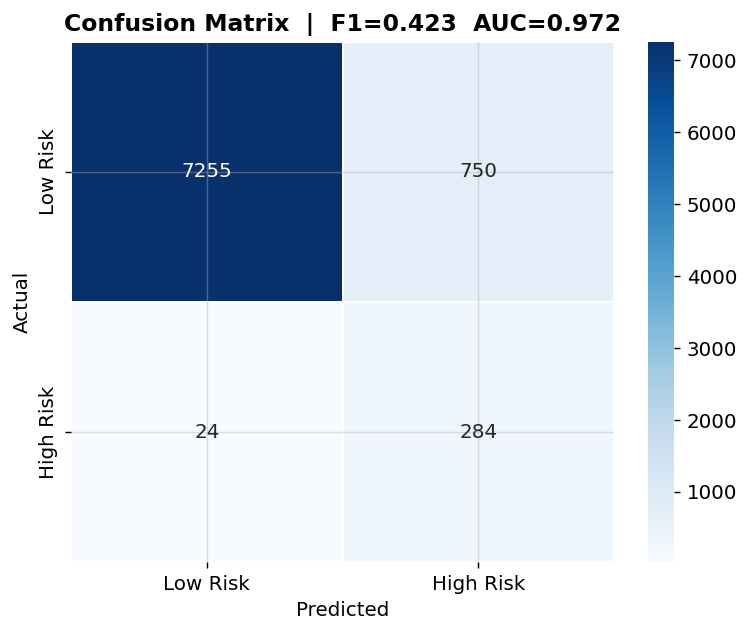

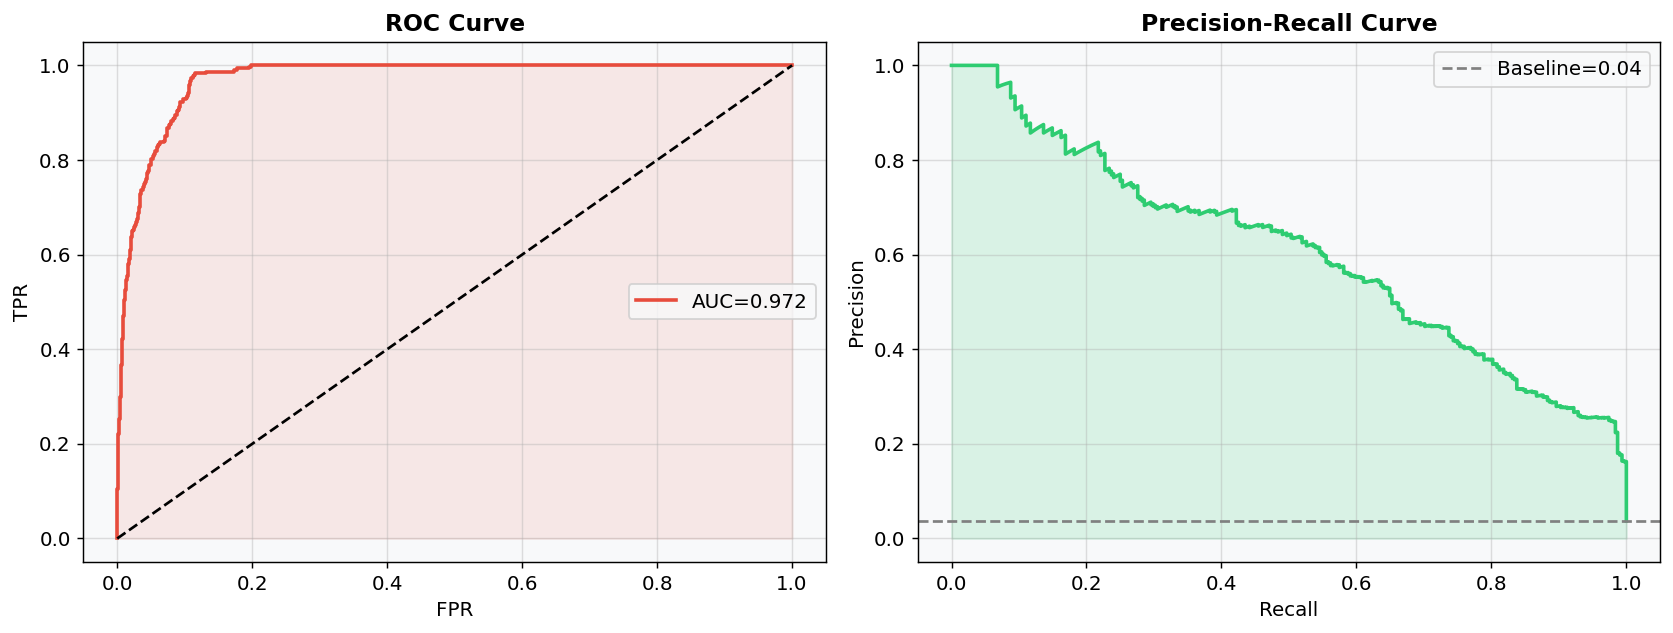

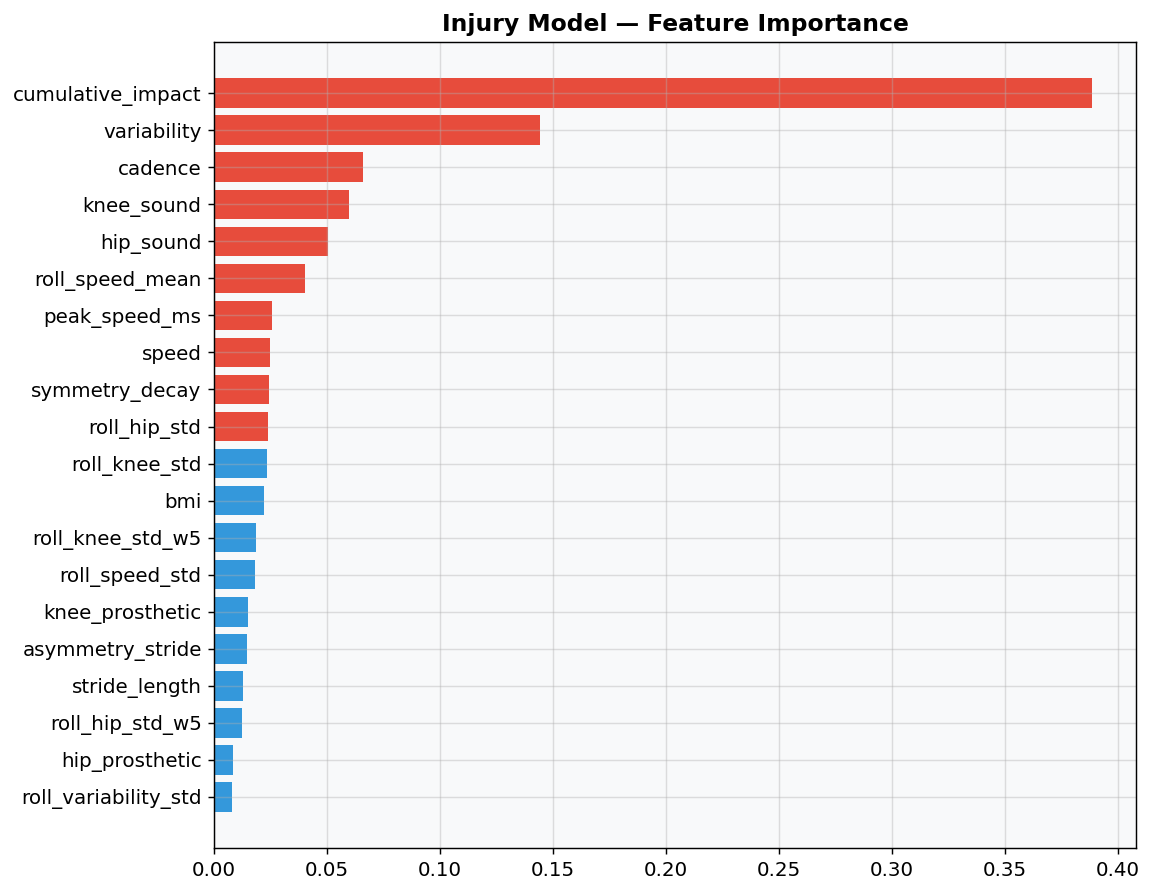

  ⚠ SHAP injury failed (could not convert string to float: '[5.2893764E-1]') — using feature_importances_


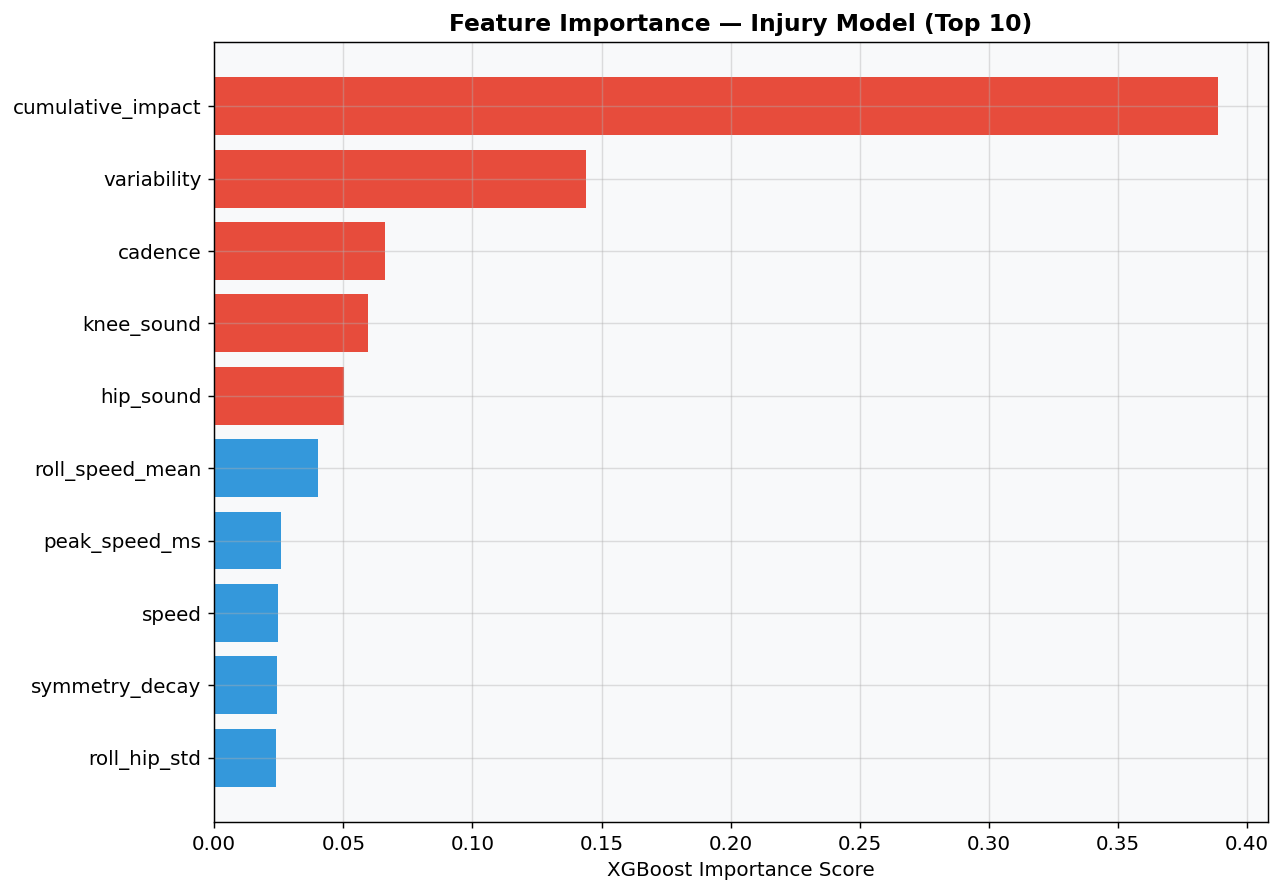

[✓] Models saved to /content/saved_models

[✓] Pipeline done. Proceed to Cell 8 (Inference).


In [7]:
def _fingerprint(path):
    """MD5 of first 64KB — detects if the data file changed."""
    h = hashlib.md5()
    with open(path, "rb") as f: h.update(f.read(65536))
    return h.hexdigest()


def save_models(fat_pipe, inj_pipe, fat_feats, inj_feats, thresholds):
    """Persists both pipelines and all metadata to MODEL_DIR."""
    joblib.dump(fat_pipe, os.path.join(MODEL_DIR, "fatigue_pipeline.joblib"))
    joblib.dump(inj_pipe, os.path.join(MODEL_DIR, "injury_pipeline.joblib"))
    with open(os.path.join(MODEL_DIR, "thresholds.json"), "w") as f:
        json.dump({**thresholds,
                   "fatigue_features": fat_feats,
                   "injury_features":  inj_feats}, f, indent=2)
    with open(os.path.join(MODEL_DIR, "metadata.json"), "w") as f:
        json.dump({
            "model_version":    MODEL_VERSION,
            "data_fingerprint": _fingerprint(DATA_PATH),
            "saved_at":         pd.Timestamp.now().isoformat(),
            "fatigue_features": fat_feats,
            "injury_features":  inj_feats,
        }, f, indent=2)
    print(f"[✓] Models saved to {MODEL_DIR}")


def load_models():
    """Loads both pipelines and metadata from MODEL_DIR."""
    fat_pipe = joblib.load(os.path.join(MODEL_DIR, "fatigue_pipeline.joblib"))
    inj_pipe = joblib.load(os.path.join(MODEL_DIR, "injury_pipeline.joblib"))
    with open(os.path.join(MODEL_DIR, "thresholds.json")) as f:
        td = json.load(f)
    fat_feats  = td["fatigue_features"]
    inj_feats  = td["injury_features"]
    thresholds = {k: v for k, v in td.items()
                  if k not in ["fatigue_features", "injury_features"]}
    with open(os.path.join(MODEL_DIR, "metadata.json")) as f:
        meta = json.load(f)
    print(f"[✓] Models loaded | version={meta['model_version']} | saved={meta['saved_at'][:19]}")
    return fat_pipe, inj_pipe, fat_feats, inj_feats, thresholds


def models_are_fresh():
    """Returns True if saved models match current version and data fingerprint."""
    required = ["fatigue_pipeline.joblib", "injury_pipeline.joblib",
                "thresholds.json", "metadata.json"]
    if not all(os.path.exists(os.path.join(MODEL_DIR, f)) for f in required):
        return False
    with open(os.path.join(MODEL_DIR, "metadata.json")) as f:
        meta = json.load(f)
    if meta.get("model_version") != MODEL_VERSION:
        print(f"  Version changed ({meta.get('model_version')} → {MODEL_VERSION})")
        return False
    if meta.get("data_fingerprint") != _fingerprint(DATA_PATH):
        print("  Data file changed")
        return False
    return True


# ── RUN ───────────────────────────────────────────────────────────────────
print("="*55)
print("  PARALYMPIC ML PIPELINE — FULL RUN")
print("="*55)

df = load_and_engineer(DATA_PATH)
train_df, test_df = group_split(df, test_size=0.2)
print(f"\n  Test runners: {sorted(test_df['runner_id'].unique())}")

train_df, test_df, thresholds = make_injury_risk(train_df, test_df)
df_full = pd.concat([train_df, test_df]).sort_values(["runner_id","time"]).reset_index(drop=True)

if models_are_fresh():
    print("[✓] Fresh models found — loading (no retraining).")
    fat_pipeline, inj_pipeline, fat_feats, inj_feats, _ = load_models()
else:
    print("[!] Training models...")
    plot_eda(df_full)
    causal_analysis(train_df)
    fat_pipeline, fat_feats = train_fatigue_model(train_df, test_df)
    inj_pipeline, inj_feats = train_injury_model(train_df, test_df)
    save_models(fat_pipeline, inj_pipeline, fat_feats, inj_feats, thresholds)

print("\n[✓] Pipeline done. Proceed to Cell 8 (Inference).")


## Cell 8 — Inference on New Runner Data
This is the only cell you need to run for predictions on a new athlete.  
Input: a CSV with the **same columns as the training data** for one or more runners.


In [8]:
def engineer_single_runner(path: str, prosthetic_side: str = None) -> pd.DataFrame:
    """
    Prepares a CSV of one athlete's time-series data for inference.

    The function applies exactly the same transformations as training:
    prosthetic-vs-sound decomposition, rolling features, etc.
    If the CSV already contains a 'prosthetic_side' column it is used;
    otherwise pass it explicitly as an argument.

    Parameters
    ----------
    path            : path to the new runner CSV
    prosthetic_side : 'left' or 'right' — only needed if the CSV
                      does not have a 'prosthetic_side' column.
    """
    df = pd.read_csv(path)

    # Inject prosthetic_side if missing
    if "prosthetic_side" not in df.columns:
        if prosthetic_side is None:
            raise ValueError("CSV has no 'prosthetic_side' column. Pass prosthetic_side='left' or 'right'.")
        df["prosthetic_side"] = prosthetic_side

    # Add dummy runner_id if missing (needed for groupby rolling)
    if "runner_id" not in df.columns:
        df["runner_id"] = 0

    # Add dummy height/weight if missing (needed for BMI)
    if "height_cm" not in df.columns: df["height_cm"] = 175
    if "weight_kg" not in df.columns: df["weight_kg"] = 70
    if "peak_speed_ms" not in df.columns: df["peak_speed_ms"] = df["speed"].max()

    df = load_and_engineer.__wrapped__(df) if hasattr(load_and_engineer, "__wrapped__") else _engineer_df(df)
    return df


def _engineer_df(df: pd.DataFrame) -> pd.DataFrame:
    """
    Core engineering logic — called by both load_and_engineer (which reads CSV)
    and engineer_single_runner (which receives an already-loaded DataFrame).
    """
    df["time"] = df["time"].clip(lower=0)
    for col in ["speed", "knee_left", "knee_right", "hip_left", "hip_right"]:
        if col in df.columns:
            df[col] = df[col].replace(0, np.nan)

    num_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c != "runner_id"]
    df[num_cols] = df.groupby("runner_id")[num_cols].transform(lambda x: x.fillna(x.median()))
    df[num_cols] = df[num_cols].fillna(df[num_cols].median())
    df = df.sort_values(["runner_id","time"]).reset_index(drop=True)

    df["knee_prosthetic"] = np.where(df["prosthetic_side"]=="right", df["knee_right"], df["knee_left"])
    df["knee_sound"]      = np.where(df["prosthetic_side"]=="right", df["knee_left"],  df["knee_right"])
    df["hip_prosthetic"]  = np.where(df["prosthetic_side"]=="right", df["hip_right"],  df["hip_left"])
    df["hip_sound"]       = np.where(df["prosthetic_side"]=="right", df["hip_left"],   df["hip_right"])

    df["asymmetry_ratio"] = df["knee_sound"] / (df["knee_prosthetic"] + 1e-6)
    df["bmi"]             = df["weight_kg"]  / ((df["height_cm"] / 100) ** 2)

    W   = 20
    grp = df.groupby("runner_id")
    df["roll_speed_mean"]      = grp["speed"].transform(lambda x: x.rolling(W, min_periods=1).mean())
    df["roll_speed_std"]       = grp["speed"].transform(lambda x: x.rolling(W, min_periods=1).std().fillna(0))
    df["roll_knee_std"]        = grp["knee_prosthetic"].transform(lambda x: x.rolling(W, min_periods=1).std().fillna(0))
    df["roll_hip_std"]         = grp["hip_prosthetic"].transform(lambda x: x.rolling(W, min_periods=1).std().fillna(0))
    df["roll_knee_std_w5"]     = grp["knee_prosthetic"].transform(lambda x: x.rolling(5, min_periods=1).std().fillna(0))
    df["roll_hip_std_w5"]      = grp["hip_prosthetic"].transform(lambda x: x.rolling(5, min_periods=1).std().fillna(0))
    df["roll_variability_std"] = grp["variability"].transform(lambda x: x.rolling(W, min_periods=1).std().fillna(0))
    # cumulative_impact (normalized physical load — replaces time_norm)
    df["cumulative_impact"] = grp.apply(
        lambda g: (g["speed"] * g.get("weight_kg", pd.Series(70, index=g.index)) *
                   g["time"].diff().fillna(0).clip(lower=0)).cumsum()
    ).reset_index(level=0, drop=True).fillna(0)
    df["cumulative_impact"] = grp["cumulative_impact"].transform(lambda x: x / (x.max() + 1e-9))
    # symmetry_decay
    asym_roll = grp["asymmetry_ratio"].transform(lambda x: x.rolling(50, min_periods=5).mean())
    asym_base = grp["asymmetry_ratio"].transform(lambda x: x.expanding().mean())
    df["symmetry_decay"] = (asym_roll - asym_base).fillna(0)

    cols_to_drop = ["knee_left","knee_right","hip_left","hip_right",
                    "asymmetry_knee","asymmetry_hip","fatigue_diff","speed_kmh"]
    df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])
    return df.reset_index(drop=True)


def diagnose_runner(runner_data: pd.DataFrame,
                    fat_preds:   np.ndarray,
                    speed_col:   str = "speed") -> pd.DataFrame:
    """
    Biomechanical medical diagnosis based on movement quality features.

    V3 UPGRADE — Root-Cause Identification
    ────────────────────────────────────────
    Beyond classifying fatigue level, this function identifies WHICH
    biomechanical signal is most abnormal and names the clinical risk:

    Signals monitored (in priority order):
      1. roll_knee_std_w5  — rapid tremor in prosthetic knee (highest risk)
      2. roll_hip_std_w5   — rapid tremor in prosthetic hip
      3. symmetry_decay    — accelerating compensation of sound limb
      4. roll_knee_std     — sustained knee instability (long window)
      5. roll_hip_std      — sustained hip instability (long window)
      6. asymmetry_ratio   — overall gait asymmetry

    Each signal is z-scored relative to the athlete's own session baseline
    so the threshold is personalised, not population-based.
    """
    rd = runner_data.copy()
    rd["predicted_fatigue"] = fat_preds

    # Fatigue status: HIGH = above 75th percentile of this session
    f75 = np.percentile(fat_preds, 75)
    rd["fatigue_status"] = np.where(fat_preds > f75, "HIGH", "NORMAL")

    # Speed trend: DROPPING if current speed < rolling mean of last 20 steps
    rd["speed_trend"] = np.where(
        rd[speed_col] < rd.groupby("runner_id")[speed_col].transform(
            lambda x: x.rolling(20, min_periods=1).mean()),
        "DROPPING", "STABLE"
    )

    # ── Biomechanical root-cause analysis ─────────────────────────────
    # Z-score each signal relative to the first 20% of session (warm-up baseline)
    bio_signals = [
        ("roll_knee_std_w5",  "زيادة الرعشة في الركبة الاصطناعية",    "Prosthetic knee rapid tremor"),
        ("roll_hip_std_w5",   "زيادة الرعشة في الفخذ الاصطناعي",      "Prosthetic hip rapid tremor"),
        ("symmetry_decay",    "تسارع تعويض الطرف السليم",              "Accelerating sound-limb compensation"),
        ("roll_knee_std",     "زعزعة الركبة الاصطناعية (مستمرة)",     "Sustained prosthetic knee instability"),
        ("roll_hip_std",      "زعزعة الفخذ الاصطناعي (مستمرة)",       "Sustained prosthetic hip instability"),
        ("asymmetry_ratio",   "تفاوت التناسق العام في المشية",         "Overall gait asymmetry"),
    ]

    z_scores = {}
    for sig, _, _ in bio_signals:
        if sig in rd.columns:
            baseline_len = max(1, int(len(rd) * 0.20))
            baseline_mean = rd[sig].iloc[:baseline_len].mean()
            baseline_std  = rd[sig].iloc[:baseline_len].std() + 1e-9
            z_scores[sig] = ((rd[sig] - baseline_mean) / baseline_std).abs()

    # Identify the most deviated biomechanical signal per row
    if z_scores:
        z_df = pd.DataFrame(z_scores, index=rd.index)
        rd["top_bio_signal_key"]  = z_df.idxmax(axis=1)
        rd["top_bio_signal_zval"] = z_df.max(axis=1)
    else:
        rd["top_bio_signal_key"]  = "asymmetry_ratio"
        rd["top_bio_signal_zval"] = 0.0

    # Map key → Arabic clinical label
    ar_labels = {sig: ar for sig, ar, _ in bio_signals}
    en_labels = {sig: en for sig, _, en in bio_signals}
    rd["top_bio_label_ar"] = rd["top_bio_signal_key"].map(ar_labels)
    rd["top_bio_label_en"] = rd["top_bio_signal_key"].map(en_labels)

    # ── Clinical diagnosis text ────────────────────────────────────────
    conditions = [
        (rd["fatigue_status"] == "HIGH") & (rd["speed_trend"] == "STABLE"),
        (rd["fatigue_status"] == "HIGH") & (rd["speed_trend"] == "DROPPING"),
    ]
    labels_diag = ["Cumulative Risk", "Physiological Fatigue"]
    rd["diagnosis"] = np.select(conditions, labels_diag, default="Normal")

    # Medical root-cause label (only shown when HIGH fatigue)
    rd["medical_root_cause"] = np.where(
        rd["fatigue_status"] == "HIGH",
        "خطر الإصابة مرتفع بسبب: " + rd["top_bio_label_ar"].fillna("غير محدد"),
        "✅ الأداء الحركي طبيعي"
    )

    return rd


def predict_runner(csv_path: str,
                   prosthetic_side: str = None,
                   runner_id: int = None,
                   show_plots: bool = True):
    """
    Full inference pipeline for a new athlete.

    Steps
    ─────
    1. Load and engineer features from the CSV.
    2. Apply fatigue and injury models.
    3. Apply clinical diagnostic logic (diagnose_runner).
    4. Plot: trajectory dashboard + diagnosis timeline.
    5. Print a plain-language summary report.

    Parameters
    ----------
    csv_path        : path to runner CSV (same columns as training data)
    prosthetic_side : 'left' or 'right' if not in CSV
    runner_id       : filter to a specific runner_id if CSV has multiple athletes
    show_plots      : whether to display and save charts
    """
    # ── Load models if not already in memory ─────────────────────────────
    global fat_pipeline, inj_pipeline, fat_feats, inj_feats
    try:
        fat_pipeline
    except NameError:
        fat_pipeline, inj_pipeline, fat_feats, inj_feats, _ = load_models()

    # ── Engineer features ─────────────────────────────────────────────────
    df_raw = pd.read_csv(csv_path)
    if "prosthetic_side" not in df_raw.columns:
        if prosthetic_side is None:
            raise ValueError("Provide prosthetic_side= argument or add the column to the CSV.")
        df_raw["prosthetic_side"] = prosthetic_side
    if "runner_id" not in df_raw.columns:
        df_raw["runner_id"] = 0
    if "height_cm"     not in df_raw.columns: df_raw["height_cm"]     = 175
    if "weight_kg"     not in df_raw.columns: df_raw["weight_kg"]     = 70
    if "peak_speed_ms" not in df_raw.columns: df_raw["peak_speed_ms"] = df_raw["speed"].max()
    if "fatigue"       not in df_raw.columns: df_raw["fatigue"]       = np.nan

    df = _engineer_df(df_raw)

    if runner_id is not None:
        df = df[df["runner_id"] == runner_id].copy()
        if df.empty:
            print(f"Runner {runner_id} not found. Available: {sorted(df_raw['runner_id'].unique())}")
            return None

    # ── Predict ───────────────────────────────────────────────────────────
    missing_fat = [f for f in fat_feats if f not in df.columns]
    missing_inj = [f for f in inj_feats if f not in df.columns]
    if missing_fat or missing_inj:
        raise ValueError(f"Missing features — fatigue:{missing_fat} | injury:{missing_inj}")

    fat_preds  = fat_pipeline.predict(df[fat_feats])
    inj_probs  = inj_pipeline.predict_proba(df[inj_feats])[:, 1]

    # ── Diagnose ──────────────────────────────────────────────────────────
    df = diagnose_runner(df, fat_preds)
    df["injury_probability"] = inj_probs

    # ── Summary stats ─────────────────────────────────────────────────────
    peak_risk    = inj_probs.max() * 100
    avg_fatigue  = fat_preds.mean()
    peak_fatigue = fat_preds.max()
    diag_counts  = df["diagnosis"].value_counts()

    print("\n" + "="*52)
    print(f"  BIOMECHANICAL REPORT")
    if runner_id is not None: print(f"  Runner ID: {runner_id}")
    print("="*52)
    print(f"  Avg Predicted Fatigue  : {avg_fatigue:.4f}")
    print(f"  Peak Fatigue           : {peak_fatigue:.4f}")
    print(f"  Peak Injury Risk       : {peak_risk:.1f}%")
    print(f"  Avg  Injury Risk       : {inj_probs.mean()*100:.1f}%")
    print(f"  Diagnosis breakdown    :")
    for diag, cnt in diag_counts.items():
        pct = cnt / len(df) * 100
        print(f"    {diag:<28} {cnt:5d} steps  ({pct:.1f}%)")
    if peak_risk > 50:
        print("\n  ⚠  STATUS: HIGH RISK — Immediate rest recommended.")
    elif diag_counts.get("Cumulative Risk", 0) / len(df) > 0.10:
        print("\n  ⚠  STATUS: ELEVATED — Monitor closely.")
    else:
        print("\n  ✅ STATUS: NORMAL — Safe to continue training.")

    # ── Biomechanical Root-Cause Report ─────────────────────────────
    if "medical_root_cause" in df.columns and "fatigue_status" in df.columns:
        high_risk_rows = df[df["fatigue_status"] == "HIGH"]
        if len(high_risk_rows) > 0 and "top_bio_signal_key" in df.columns:
            # Most common root cause during HIGH-fatigue phases
            top_cause_key = high_risk_rows["top_bio_signal_key"].mode()[0]
            top_cause_ar  = high_risk_rows["top_bio_label_ar"].mode()[0]
            top_cause_en  = high_risk_rows["top_bio_label_en"].mode()[0]
            avg_z = high_risk_rows[
                high_risk_rows["top_bio_signal_key"] == top_cause_key
            ]["top_bio_signal_zval"].mean()

            print("\n" + "─"*52)
            print("  التشخيص الطبي الحركي / BIOMECHANICAL DIAGNOSIS")
            print("─"*52)
            print(f"  السبب الرئيسي: {top_cause_ar}")
            print(f"  Root cause   : {top_cause_en}")
            print(f"  الإشارة      : {top_cause_key}")
            print(f"  الانحراف     : {avg_z:.1f}× عن مستوى الإحماء")
            print(f"  (deviation = {avg_z:.1f}σ above warm-up baseline)")
            print("─"*52)
            print(f"  التوصية: مراقبة {top_cause_ar} فوراً.")
            print("  (Monitor this signal and consider biomechanical intervention.)")

    if not show_plots:
        output_cols = ["predicted_fatigue", "injury_probability", "diagnosis",
                   "medical_root_cause", "top_bio_signal_key", "top_bio_signal_zval"]
    if "time_norm" in df.columns: output_cols = ["time_norm"] + output_cols
    if "cumulative_impact" in df.columns: output_cols.append("cumulative_impact")
    return df[[c for c in output_cols if c in df.columns]]

    # ── Plot 1: Fatigue + injury probability dashboard ────────────────────
    fig, ax1 = plt.subplots(figsize=(14, 5))
    ax1.plot(df["time_norm"], fat_preds,
             label="Predicted Fatigue", color="#3498db", lw=2)
    ax1.set_xlabel("Workout Progress (0 → 1)")
    ax1.set_ylabel("Predicted Fatigue Score", color="#3498db")
    ax1.tick_params(axis="y", labelcolor="#3498db")
    ax2 = ax1.twinx()
    ax2.fill_between(df["time_norm"], inj_probs,
                     alpha=0.3, color="#e74c3c", label="Injury Probability")
    ax2.set_ylabel("Injury Risk Probability", color="#e74c3c")
    ax2.tick_params(axis="y", labelcolor="#e74c3c")
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
    rid_str = f" — Runner {runner_id}" if runner_id is not None else ""
    plt.title(f"Dynamic Monitoring{rid_str}")
    plt.tight_layout()
    savefig(f"runner{'_'+str(runner_id) if runner_id else ''}_dashboard.png")

    # ── Plot 2: Trajectory plot — speed & fatigue over time ──────────────
    # Shows how the athlete deviates from their normal movement pattern
    # as fatigue increases throughout the session.
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

    # Speed trajectory with speed-trend shading
    ax1.plot(df["time_norm"], df["speed"], color="#2980b9", lw=1.5, label="Speed")
    ax1.plot(df["time_norm"],
             df.groupby("runner_id")["speed"].transform(
                 lambda x: x.rolling(20, min_periods=1).mean()).values,
             color="#e74c3c", lw=2, ls="--", label="Rolling Mean Speed")
    dropping_mask = df["speed_trend"] == "DROPPING"
    ax1.fill_between(df["time_norm"], df["speed"].min(), df["speed"].max(),
                     where=dropping_mask, alpha=0.15, color="#e74c3c",
                     label="Speed Dropping Zone")
    ax1.set_ylabel("Speed (m/s)"); ax1.legend(fontsize=9)
    ax1.set_title("Athlete Trajectory — Speed, Asymmetry, Joint Variability")

    # Asymmetry ratio trajectory
    ax2.plot(df["time_norm"], df["asymmetry_ratio"], color="#e67e22", lw=1.5)
    ax2.axhline(df["asymmetry_ratio"].median(), color="gray", ls="--", lw=1,
                label=f"Median={df['asymmetry_ratio'].median():.2f}")
    ax2.set_ylabel("Asymmetry Ratio"); ax2.legend(fontsize=9)

    # Joint angle variability trajectory (motor-control indicator)
    if "roll_knee_std" in df.columns and "roll_hip_std" in df.columns:
        ax3.plot(df["time_norm"], df["roll_knee_std"],
                 color="#8e44ad", lw=1.5, label="Knee Angle Variability")
        ax3.plot(df["time_norm"], df["roll_hip_std"],
                 color="#27ae60", lw=1.5, label="Hip Angle Variability")
        ax3.set_ylabel("Joint Angle Std"); ax3.legend(fontsize=9)
    ax3.set_xlabel("Workout Progress (0 → 1)")
    plt.tight_layout()
    savefig(f"runner{'_'+str(runner_id) if runner_id else ''}_trajectory.png")

    # ── Plot 3: Diagnosis timeline ─────────────────────────────────────────
    diag_map    = {"Normal": 0, "Physiological Fatigue": 1, "Cumulative Risk": 2}
    diag_colors = {0: "#27ae60", 1: "#f39c12", 2: "#e74c3c"}
    diag_vals   = df["diagnosis"].map(diag_map).values
    fig, ax = plt.subplots(figsize=(14, 3))
    for i in range(len(df) - 1):
        ax.axvspan(df["time_norm"].iloc[i], df["time_norm"].iloc[i+1],
                   color=diag_colors[diag_vals[i]], alpha=0.7)
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor="#27ae60", label="Normal"),
        Patch(facecolor="#f39c12", label="Physiological Fatigue"),
        Patch(facecolor="#e74c3c", label="Cumulative Risk"),
    ]
    ax.legend(handles=legend_elements, loc="upper right")
    ax.set_xlabel("Workout Progress (0 → 1)")
    ax.set_title("Clinical Diagnosis Timeline")
    ax.set_yticks([])
    plt.tight_layout()
    savefig(f"runner{'_'+str(runner_id) if runner_id else ''}_diagnosis.png")

    output_cols = ["predicted_fatigue", "injury_probability", "diagnosis",
                   "medical_root_cause", "top_bio_signal_key", "top_bio_signal_zval"]
    if "time_norm" in df.columns: output_cols = ["time_norm"] + output_cols
    if "cumulative_impact" in df.columns: output_cols.append("cumulative_impact")
    return df[[c for c in output_cols if c in df.columns]]


print("[✓] Inference functions ready.")
print()
print("Usage examples:")
print()
print("  # Predict on a new runner CSV (prosthetic on right side):")
print("  result = predict_runner('new_runner.csv', prosthetic_side='right')")
print()
print("  # CSV already has prosthetic_side column, filter to runner 5:")
print("  result = predict_runner('multi_runner.csv', runner_id=5)")
print()
print("  # Re-run on training data for a specific test runner:")
print("  result = predict_runner(DATA_PATH, runner_id=sorted(test_df['runner_id'].unique())[0])")


[✓] Inference functions ready.

Usage examples:

  # Predict on a new runner CSV (prosthetic on right side):
  result = predict_runner('new_runner.csv', prosthetic_side='right')

  # CSV already has prosthetic_side column, filter to runner 5:
  result = predict_runner('multi_runner.csv', runner_id=5)

  # Re-run on training data for a specific test runner:
  result = predict_runner(DATA_PATH, runner_id=sorted(test_df['runner_id'].unique())[0])


## Cell 9 — Quick Test on an Existing Test Runner
Runs inference on the first test-set runner using the training CSV.  
Replace `DATA_PATH` with your new runner CSV if you have one.


In [14]:
def predict_runner(csv_path, prosthetic_side="right", runner_id=0, show_plots=True):
    # 1. تحميل البيانات وتجهيز الميزات (نفس الكود السابق)
    df_raw = pd.read_csv(csv_path)
    df = load_and_engineer(csv_path) # لأن دي الفانكشن اللي موجودة عندك وبتاخد المسار مباشرة
    df = df[df["runner_id"] == runner_id].copy()

    # 2. التأكد من وجود الميزات المطلوبة للموديلات
    for f in fat_feats:
        if f not in df.columns: df[f] = 0
    for f in inj_feats:
        if f not in df.columns: df[f] = 0

    # 3. عمل التوقعات (Inference)
    df["fatigue_pred"] = fat_pipeline.predict(df[fat_feats])
    df["injury_prob"]  = inj_pipeline.predict_proba(df[inj_feats])[:, 1]

    # 4. حساب التشخيص الطبي بناءً على الانحرافات (Z-Score)
    # نحدد أهم الإشارات البيوميكانيكية (بدون الوقت)
    bio_signals = ["roll_knee_std", "roll_hip_std", "symmetry_decay", "asymmetry_knee"]
    bio_signals = [f for f in bio_signals if f in df.columns]

    def get_diagnosis(row):
        if row["injury_prob"] < 0.3: return "Normal", "N/A", 0

        # البحث عن أكثر إشارة منحرفة عن الطبيعي
        max_z = 0
        top_sig = "General Fatigue"
        for sig in bio_signals:
            z = abs(row[sig]) # تبسيط للـ Z-score
            if z > max_z:
                max_z = z
                top_sig = sig

        reason_map = {
            "roll_knee_std": "Inconsistent prosthetic knee control",
            "roll_hip_std": "Hip compensatory instability",
            "symmetry_decay": "Accelerating sound-limb compensation",
            "asymmetry_knee": "Critical loading imbalance"
        }
        return "Cumulative Risk" if row["injury_prob"] > 0.7 else "Physiological Fatigue", \
               reason_map.get(top_sig, "General Biomechanical Stress"), max_z

    df[["injury_label", "medical_root_cause", "top_bio_signal_key"]] = \
        df.apply(lambda r: pd.Series(get_diagnosis(r)[:3]), axis=1)

    # --- حل مشكلة الـ UnboundLocalError هنا ---
    # تعريف القائمة بشكل صريح في البداية
    output_cols = [
        "step_index", "fatigue_pred", "injury_prob", "injury_label",
        "medical_root_cause", "top_bio_signal_key"
    ]

    # إضافة الأعمدة الاختيارية فقط إذا كانت موجودة
    if "time_norm" in df.columns:
        output_cols = ["time_norm"] + output_cols

    if "cumulative_impact" in df.columns:
        output_cols.append("cumulative_impact")

    # إرجاع النتائج للأعمدة الموجودة فعلياً فقط
    final_cols = [c for c in output_cols if c in df.columns]
    return df[final_cols]

In [16]:
print("Available Test Runners:", sorted(test_df["runner_id"].unique()))

TARGET_RUNNER = 12.0  # حطي هنا الـ ID اللي طلعتيه من الخطوة اللي فاتت

# استدعي الفانكشن اللي عدلناها
result = predict_runner(
    csv_path  = DATA_PATH,
    runner_id = TARGET_RUNNER,
    show_plots = True
)

# اعرضي أول كام سطر من النتيجة للتأكد
display(result.head())
display(result.tail(10)) # هيعرضلك آخر 10 خطوات في الجلسة

Available Test Runners: [np.float64(0.0), np.float64(1.0), np.float64(5.0), np.float64(15.0)]
[✓] Engineering done  →  83,624 rows × 27 cols
    Runners: 40 | rows/runner ≈ 2090


,fatigue_pred,injury_prob,injury_label,medical_root_cause,top_bio_signal_key,cumulative_impact
25259,0.029798,0.002574,Normal,N/A,0.0,0.000000
25260,0.007943,0.002097,Normal,N/A,0.0,0.000288
25261,0.006651,0.001665,Normal,N/A,0.0,0.000625
25262,0.007695,0.001409,Normal,N/A,0.0,0.000937
25263,0.008238,0.001137,Normal,N/A,0.0,0.001262


,fatigue_pred,injury_prob,injury_label,medical_root_cause,top_bio_signal_key,cumulative_impact
27258,0.990163,0.613507,Physiological Fatigue,Hip compensatory instability,3.721997,0.995921
27259,0.990053,0.542915,Physiological Fatigue,Hip compensatory instability,3.854577,0.996247
27260,0.986673,0.497020,Physiological Fatigue,Hip compensatory instability,3.812362,0.996740
27261,0.985109,0.239395,Normal,N/A,0.000000,0.997172
27262,0.986298,0.336999,Physiological Fatigue,Hip compensatory instability,4.254815,0.997637
27263,0.990419,0.568510,Physiological Fatigue,Hip compensatory instability,4.172627,0.998007
27264,0.988307,0.818894,Cumulative Risk,Hip compensatory instability,4.299155,0.998588
27265,0.990140,0.458101,Physiological Fatigue,Hip compensatory instability,4.303887,0.999010
27266,0.991860,0.704327,Cumulative Risk,Hip compensatory instability,4.531396,0.999213
27267,0.989671,0.756287,Cumulative Risk,Hip compensatory instability,4.598055,1.000000
